# QCTO Workplace Module

### Project Title: "FraudBuster" : A Predictive Model for Detecting Fraudulent Automobile Insurance Claims
#### Done By: Moosa Molibeli

© ExploreAI 2024

----

![Cars](pexels-mikebirdy-120049.jpg)

<a id="cont"></a>
## Table of Contents

<a href=#one>1. Background Context</a>

<a href=#two>2. Importing Packages</a>

<a href=#three>3. Data Collection and Description</a>

<a href=#four>4. Loading Data </a>

<a href=#five>5. Data Cleaning and Filtering</a>

<a href=#six>6. Exploratory Data Analysis (EDA)</a>

<a href=#seven>7. Feature Selection </a>

<a href=#eight>8. Modeling </a>

<a href=#nine>9. Evaluation and Validation</a>

<a href=#ten>10. Final Model</a>

<a href=#eleven>11. Extracting Data for PowerBI Visualisation</a>

<a href=#twelve>12. Conclusion and Future Work</a>

<a href=#thirteen>13. References</a>

---
<a id="one"></a>
## Background Context
<a href=#cont>Back to Table of Contents</a>

Insurance fraud contributes between 5 to 10 percent of total claims and is costing insurance companies about 31 billion dollars annually, with no slowing down detected in these numbers (Viaene et al., 2007). In order to make up for the losses from these fraudulent claims, insurance companies often raise each policyholder's premiums. This then means that the current and predicted monterary loss from fraudulent insurance claims is not only a concern for insurance companies, but also for customers. Boyer (2000), quoted a study that stated that in automobile insurance claims, questionable medical claims added an upward of 13 billion dollars to the national's total automobile insurance bill in 1993. 

Amongst the different types of insurance, car insurance is found to be the most predominant. Car insurance fraud can be brought about by a myriad of forms such as staging an accident, duplicating claims for the same injury, faking an injury, and many other misrepresentations (Derrig, 2002). In order to be able to detect these fraudulent claims, insurance companies and their fraud detectives need to know what charateristics to look out for. Since there are numerous factors and situations that can be attributed to a fraudulent claim, this proves to be a very difficult task. What adds to the complexity is the fact that insurance companies do not often share their claims with one another, which would collectively enhance the information known on fraudulent claims. Thus one of the goals of this paper is to provide a general statistical learning algorithm for building a predictive model for practical use in the insurance industry. 

The primary goal of this paper is to identify fraudulent car insurance claims by finding patterns that typically relate to a fraudulent claim. One approach in identifying these types of claims consists of using cost-related data, such as the cost of the car's damage and auditing costs (Viaene et al., 2007). Another common approach is to evaluate the non cost-related data associated with fraudulent claims, such as the policyholder's demographic information, their insurance history, etc. The latter method will be the approached applied in this paper. Thus, in this study, I will be looking for which variables affect fraudulent claims and the patterns typically related to fraudulent claims. 

There have been a few studies before that have used statistical methods to predict fraud claims in the car insurance industry. One such as study by Ciaene, et al. (2002) conducted a study on a dataset of 1399 personal injury protection (PIP) claims from 1993 accidents collected by the Automobile Insurance Bureau (AIB). The study used various classification techniqures including logistic regresion, decision tree, k-nearest neighbour, Baysian learning multilayer perception neutral network support vector machines, naive Bayes, and the tree-augmented naive Bayes classification algorthims. In another Spanish car insurance fraud detection study, multiple logit models were used for multinomial outcomes (Caudill, Ayuso and Guillen, 2005). Another study, in economics application, used discrete choice models on claims data for car accidents that occured from 1993 to 1996 in oder to detect car insurance fraud and misclassified claims ((Artis, Ayuso and Cuillen, 2002).

Wang and Xu (2018) proposed a deep learning model for insurance fraud detection that used Latent Dirichlet Allocation (LDA) with their data including both categorical and numeric variables from a Chinese insurance company's claims. Nian et al. (2016) had already proposed an unsupervised spectral ranking method prior, that illustrated that the spectral optimization in SRA could be viewed as a relaxation of an unsupervised SVM problem. 
With the car insurance claims dataset, they provided a solution that the choice of fraud ranking reference could be made based on whether the cardinality of the smaller class was sufficiently large, and demonstrated that the proposed SRA yielded good performance for a few similarity measures.
Most recently, Moon, Pu, and Ceglia (2019) used the logistic regression, LASSO, Random Forest and Support Vector models in an attempt to predict fraudulent claims.

Given today's statical learning algorithms, I am confident that predictive modeling can more accurately classify a fraudelent claim. There are several predictive methods that could be used in this detection. The most common and fundamental for classifying fraudulent claims would be logistic regression, with an emphasis on variable importance. A goal of this paper is to provide a general statistical algorithm that is best suited for highly biased data for practical us in an insurance compant. This paper will use logistic regression, while Random Forest is used as the non-parametric ensemble method. Gradient Boosting models, like XGBoost or LightGBM, are known for their strong performance on a wide variety of classification problems, including fraud detection. For this paper, I will use the XGBoost gradient boosting model. 

Insurance fraud detection is important in helping to prevent significant financial losses, maintaining customer confidence and protecting the insurer's reputation, as well as ensuring adherence to industry regulations. So once an advanced fraud detection system has been put in place, insurers will be able to streamline the claims process and optimise resource allocation. It will also enable the insurer to understand the vulnerabilities in their processes and strengthen defenses against future attempts. Fraud detection is an important aspect of modern financial institutions, especially in technical areas that are important and sensitive. The frequency of financial frauds has increased noticeably, particularly in the car insurance industry, further reinforcing the signidficance of predictive modelling of fraudulent insurance claims.

![Car Accident](pexels-dominika-kwiatkowska-1796968-3368844.jpg)

---
<a id="two"></a>
## Importing Packages
<a href=#cont>Back to Table of Contents</a>

**Please Note:**
*The below are all the libraries I believe I will need for this project. This list will be adjusted as needed throughout the project*

In [271]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# model libraries for classification
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# evaluation metrics for classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve


# feature engineering & selection techniques
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# model validation
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')


In [272]:
#!pip install category-encoders

---
<a id="three"></a>
## Data Collection and Description
<a href=#cont>Back to Table of Contents</a>

The dataset used for this project is the 'Insurance_claims_raw.xlsx' dataset. It includes various variables related to insurance claims, such as customer duration, age, policy details, and incident specifics. The dataset was sourced from the Explore AI GitHub repository, which was forked onto my own GitHub account in order to gain full access to it. 

The dataset comprises both numerical and categorical data, including policy numbers, claim amounts, incident types, and demographic details like age and educational level. It is structured in such a way as to cover the entire scope of insurance claims, from policy initiation to incident reporting, enabling detailed analysis of fraudulent activities. From observation, the dataset's comprehensive nature supports robust fraud detection modeling. 

From quick observation of the dataset, it comprises 1000 observations and 40 variables.

Below is an explanation of each variable in the dataset:

In [273]:
# Data for the table
data = {
    "Column Name": [
        "age", "policy_number", "policy_bind_date", "policy_state", "policy_csl",
        "policy_deductable", "policy_annual_premium", "umbrella_limit", "insured_zip",
        "insured_sex", "insured_education_level", "insured_occupation", "insured_hobbies",
        "insured_relationship", "capital-gains", "capital-loss", "incident_date",
        "incident_type", "collision_type", "incident_severity", "authorities_contacted",
        "incident_state", "incident_city", "incident_location", "incident_hour_of_the_day",
        "number_of_vehicles_involved", "property_damage", "bodily_injuries", "witnesses",
        "police_report_available", "total_claim_amount", "injury_claim", "property_claim",
        "vehicle_claim", "auto_make", "auto_model", "auto_year", "fraud_reported"
    ],
    "Description": [
        "Age of the insured person.", "Unique number assigned to the insurance policy.",
        "Date when the policy was initiated.", "State where the policy was issued.",
        "Combined Single Limit – Coverage limit per accident.", "Amount the insured pays out of pocket before the insurer pays the claim.",
        "Yearly premium amount for the insurance policy.", "Additional liability coverage limit beyond the standard policy.",
        "ZIP code of the insured individual.", "Gender of the insured individual.", 
        "Education level of the insured (e.g., MD, PhD, Associate).", "Occupation of the insured person.",
        "Hobbies of the insured individual.", "Relationship status of the insured (e.g., husband, unmarried).",
        "Profit from the sale of assets like stocks or property.", "Loss from the sale of assets.",
        "Date when the incident occurred.", "Type of incident (e.g., Vehicle Theft, Single Vehicle Collision).",
        "Specific type of collision (e.g., Rear Collision, Front Collision).", 
        "Severity of the incident (e.g., Minor Damage, Major Damage).", 
        "Authorities that were contacted post-incident (e.g., Police).", "State where the incident took place.",
        "City where the incident occurred.", "Exact location/address of the incident.", 
        "Hour of the day when the incident occurred.", "Total number of vehicles involved in the incident.",
        "Whether there was property damage (YES, NO, or ? if uncertain).", "Number of bodily injuries sustained during the incident.",
        "Number of witnesses present at the time of the incident.", "Indicates whether a police report was available (YES, NO, or ? if uncertain).",
        "Total claim amount for the incident.", "Claim amount for injuries.", "Claim amount for property damages.",
        "Claim amount for vehicle damages.", "Make/brand of the vehicle involved.", "Model of the vehicle involved.",
        "Year of manufacture of the vehicle.", "Indicates whether the claim was fraudulent (Y for Yes, N for No)."
    ]
}

# Create a DataFrame
Data_Description = pd.DataFrame(data)

# Display the DataFrame
Data_Description


,Column Name,Description
0,age,Age of the insured person.
1,policy_number,Unique number assigned to the insurance policy.
2,policy_bind_date,Date when the policy was initiated.
3,policy_state,State where the policy was issued.
4,policy_csl,Combined Single Limit – Coverage limit per acc...
5,policy_deductable,Amount the insured pays out of pocket before t...
6,policy_annual_premium,Yearly premium amount for the insurance policy.
7,umbrella_limit,Additional liability coverage limit beyond the...
8,insured_zip,ZIP code of the insured individual.
9,insured_sex,Gender of the insured individual.


---
<a id="four"></a>
## Loading Data
<a href=#cont>Back to Table of Contents</a>

In [274]:
# loading the dataset 
df = pd.read_excel('insurance_claims_raw.xlsx')
pd.set_option("display.max_columns", None)
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48.0,521585,2014-10-17,OH,250/500,1000.0,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300.0,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610.0,6510.0,13020.0,52080,Saab,92x,2004,Y,NaN
1,228,42.0,342868,2006-06-27,IN,250/500,2000.0,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0.0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070.0,780.0,780.0,3510,Mercedes,E400,2007,Y,NaN
2,134,29.0,687698,2000-09-06,OH,100/300,2000.0,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100.0,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650.0,7700.0,3850.0,23100,Dodge,RAM,2007,N,NaN
3,256,41.0,227811,1990-05-25,IL,250/500,2000.0,1415.74,6000000,608117,FEMALE,PhD,armed-forces,NaN,unmarried,48900.0,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400.0,6340.0,6340.0,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44.0,367455,2014-06-06,IL,500/1000,1000.0,1583.91,6000000,610706,MALE,Associate,sales,NaN,unmarried,66000.0,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500.0,1300.0,650.0,4550,Accura,RSX,2009,N,NaN


---
<a id="five"></a>
## Data Cleaning and Filtering
<a href=#cont>Back to Table of Contents</a>

#### Introduction

Data cleaning and preprocessing are essential steps in preparing a dataset for analysis. These processes involve handling missing values, duplicates &  outliers. In this stage, I will endeavour to perserve the quality and integrity of the dataset while preparing it for unbiased insights that will not mislead stakeholders

#### Step 1:
##### Understanding the data structure

We will begin firstly by understanding the data structure by displaying things such as the shape of the dataframe to understand how many observations and predictors I have in the dataset, and the data types to ensure they are appropriate, but also to understand the type of manipulation that will be required during feature selection and prediction stages. Lastly, I will also take a look at the basic statistics. This should give us a little more information around spread & any obvious outliers in the data. 

But first, I will start by creating a copy of our dataframe that I will use for the remainder of the project. This is to ensure if anything is accidently lost in the clean-up stage, we can revert back to the original dataset.

In [275]:
# creating a copy of the dataset
df_copy = df.copy()

In [276]:
# getting the shape of the dataset
df_copy.shape

(1000, 40)

Observation:

There are 1000 observations in our dataset and 39 predictor variables that we will be working with. Feature selection might be a necessary step here so as to avoid overfitting as there are quite a few predictor variables. 

In [277]:
# displaying the first few rows of the dataset to get a sense of the columns in the dataset
df_copy.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48.0,521585,2014-10-17,OH,250/500,1000.0,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300.0,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610.0,6510.0,13020.0,52080,Saab,92x,2004,Y,NaN
1,228,42.0,342868,2006-06-27,IN,250/500,2000.0,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0.0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070.0,780.0,780.0,3510,Mercedes,E400,2007,Y,NaN
2,134,29.0,687698,2000-09-06,OH,100/300,2000.0,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100.0,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650.0,7700.0,3850.0,23100,Dodge,RAM,2007,N,NaN
3,256,41.0,227811,1990-05-25,IL,250/500,2000.0,1415.74,6000000,608117,FEMALE,PhD,armed-forces,NaN,unmarried,48900.0,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400.0,6340.0,6340.0,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44.0,367455,2014-06-06,IL,500/1000,1000.0,1583.91,6000000,610706,MALE,Associate,sales,NaN,unmarried,66000.0,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500.0,1300.0,650.0,4550,Accura,RSX,2009,N,NaN


In [278]:
# getting a summary of the dataframe in terms of data types
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           1000 non-null   int64         
 1   age                          998 non-null    float64       
 2   policy_number                1000 non-null   int64         
 3   policy_bind_date             1000 non-null   datetime64[ns]
 4   policy_state                 1000 non-null   object        
 5   policy_csl                   1000 non-null   object        
 6   policy_deductable            998 non-null    float64       
 7   policy_annual_premium        997 non-null    float64       
 8   umbrella_limit               1000 non-null   int64         
 9   insured_zip                  1000 non-null   int64         
 10  insured_sex                  1000 non-null   object        
 11  insured_education_level      999 non-null   

Observation: 

* The dataset seems largely complete, with only a few columns exhibiting missing data. Handling the missing values appropriately is crucial for accurate analysis.

* The dataset includes a mix of numerical, categorical, and datetime columns, which allows for diverse types of analysis.
Categorical columns might need encoding for machine learning tasks.

* The dataframe also has the _c39 column, which is entirely missing (NaN), and it might be a good candidate for removal.

In [279]:
# getting the basic statistics of the variables in the dataset
print(df_copy.describe())

       months_as_customer         age  policy_number  \
count         1000.000000  998.000000    1000.000000   
mean           203.954000   38.962926  546238.648000   
min              0.000000   19.000000  100804.000000   
25%            115.750000   32.000000  335980.250000   
50%            199.500000   38.000000  533135.000000   
75%            276.250000   44.000000  759099.750000   
max            479.000000   64.000000  999435.000000   
std            115.113174    9.135425  257063.005276   

                    policy_bind_date  policy_deductable  \
count                           1000         998.000000   
mean   2002-02-08 04:40:47.999999872        1134.268537   
min              1990-01-08 00:00:00         500.000000   
25%              1995-09-19 00:00:00         500.000000   
50%              2002-04-01 12:00:00        1000.000000   
75%              2008-04-21 12:00:00        2000.000000   
max              2015-02-22 00:00:00        2000.000000   
std                    

Observation:

*Statistical Summary:*

* Numerical features like age, policy_annual_premium, total_claim_amount, etc., are within reasonable ranges, though there are some potential outliers (e.g., negative capital-gains values).
* Policy deductibles have a significant range of values (min = 500, max = 2000), which may warrant some attention depending on your domain knowledge.

*Date-related Columns:*

* policy_bind_date data spans from 1990 to 2015. This is quite a large range.
* incident_date appears the incidents mostly happened in January and February of 2015. This gives us an idea of potential time-based patterns, though the data might be limited in time span as this is likely a snapshot in time.

*Anomalies:*

* I noted that the umbrella limit has negative values, which is uncharacteristic of the nature of umbrella limits and this will need further unpacking

*Outliers:*

* The policy_annual_premium column seems to be a range from low premiums (433.33) to extremely high ones (2047.59). This is plausible as size of premium could range dependent on a number of factors
* The total_claim_amount column ranges from 100 to ~114,920, which might need a closer look for skewness or outliers.
  
*Redundant Columns or Candidate Columns for Dropping:*

* As aforementioned, the _c39 column is entirely missing, so it can be safely dropped.
* policy_number is simply a unique identifier for each policy. This could be useful for identifying individual policies but is unlikely to provide predictive value for fraud detection, so it may Lalso be dropped.
* Insured_zip might be too granular as it contains ZIP codes. As such, zip codes are likely to have high cardinality which could lead to sparse encoding when we have to encode the features.
* auto_make and auto_model might not be important for predicting fraud and they are likely to have high cardinality as well. This high cardinality issue is likely to be present in the incident_location, policy_state and incident_city columns as well. And for this reason, will be removed.
* incident_hour_of_the_day column might not contribute to fraud detection as there is no reason to reasonably believe that the time of day an incident occurs carries any predictive power.
* months_as_customer does not seem like it would provide any useful information nor carry any predictive power for this use case.
* total_claim_amount is the sum of the individual claim amounts (injury, property, vehicle). Since we already have the breakdown of the claims, this column is redundant

In [280]:
# dropping redundant columns
df_copy.drop(columns=['policy_number', '_c39', 'insured_zip', 'auto_make', 'auto_model', 'incident_location', 'policy_state', 'incident_city', 'incident_hour_of_the_day', 'months_as_customer', 
                      'total_claim_amount'], inplace=True)

#### Step 2:
##### Handling Missing Values


Missing values can introduce inaccuracies and create bias in the analysis. So, it is important identify them and handle them appropriately. To do this, I will get the sum of all isnull rows for each column in the datafra.).

In [281]:
# checking for missing values
df_copy.isnull().sum()

age                             2
policy_bind_date                0
policy_csl                      0
policy_deductable               2
policy_annual_premium           3
umbrella_limit                  0
insured_sex                     0
insured_education_level         1
insured_occupation              0
insured_hobbies                 2
insured_relationship            0
capital-gains                   2
capital-loss                    0
incident_date                   0
incident_type                   0
collision_type                  0
incident_severity               0
authorities_contacted          93
incident_state                  2
number_of_vehicles_involved     0
property_damage                 0
bodily_injuries                 0
witnesses                       0
police_report_available         0
injury_claim                    1
property_claim                  1
vehicle_claim                   0
auto_year                       0
fraud_reported                  0
dtype: int64

Observation:

There are 9 columns with missing/null values, majority of which have less than 4 missing values. I will be using thmedian imputationon method to replace the missinnumerical g valu and mode imputation method to repplace the missing categorical valuesesMedian imputation is robust to outliers and preserves the central tendency of the data when replacing missing values. Mode imputation is effective for categorical data as it replaces missing values with the most frequent category, maintaining the distribution of the data.umn.

In [282]:
# imputing missing values in numerical columns with the median 

df_copy['age'].fillna(df_copy['age'].median(), inplace=True) 
df_copy['policy_deductable'].fillna(df_copy['policy_deductable'].median(), inplace=True) 
df_copy['capital-gains'].fillna(df_copy['capital-gains'].median(), inplace=True)  
df_copy['policy_annual_premium'].fillna(df_copy['policy_annual_premium'].median(), inplace=True)  
df_copy['injury_claim'].fillna(df_copy['injury_claim'].median(), inplace=True)  
df_copy['property_claim'].fillna(df_copy['property_claim'].median(), inplace=True)  
df_copy['vehicle_claim'].fillna(df_copy['vehicle_claim'].median(), inplace=True)  

In [283]:
# categorical columns imputation with the mode (most frequent category)

df_copy['insured_education_level'].fillna(df_copy['insured_education_level'].mode()[0], inplace=True)  
df_copy['insured_hobbies'].fillna(df_copy['insured_hobbies'].mode()[0], inplace=True) 
df_copy['authorities_contacted'].fillna(df_copy['authorities_contacted'].mode()[0], inplace=True)  
df_copy['incident_state'].fillna(df_copy['incident_state'].mode()[0], inplace=True)  

In [284]:
# verfiying that all missing data was deleted properly
df_copy.isnull().sum()

age                            0
policy_bind_date               0
policy_csl                     0
policy_deductable              0
policy_annual_premium          0
umbrella_limit                 0
insured_sex                    0
insured_education_level        0
insured_occupation             0
insured_hobbies                0
insured_relationship           0
capital-gains                  0
capital-loss                   0
incident_date                  0
incident_type                  0
collision_type                 0
incident_severity              0
authorities_contacted          0
incident_state                 0
number_of_vehicles_involved    0
property_damage                0
bodily_injuries                0
witnesses                      0
police_report_available        0
injury_claim                   0
property_claim                 0
vehicle_claim                  0
auto_year                      0
fraud_reported                 0
dtype: int64

#### Step 3: 
##### Handling Negative Values of Umbrella Limit 

In a car insurance claims, it's generally not expected for the umbrella limit to have negative values. The umbrella limit represents a maximum amount of coverage, so it should always be zero or a positive number. It is important to unpack the 'umbrella_limit' column in order to decide how to best handle it.

In [285]:
# understanding the intial values of the umbrella limit column
print(df_copy['umbrella_limit'].unique())

[       0  5000000  6000000  4000000  3000000  8000000  7000000  9000000
 10000000 -1000000  2000000]


Observation:

From the initial values, it looks like I have a mix of valid positive values, a zero, and a single negative value (-1,000,000). This negative entry might be the result of data entry issues. However, let me investigate further to further unpack. I will now check the datatype of the column. 

In [286]:
# getting an understanding of the datatype of the column
print(df_copy['umbrella_limit'].dtype)

int64


Observation:

I highly suspect these negative values are a data entry issue. To correct this, I will convert the 'umbrella_limit' column into absolute values of the current entries. This is correct the single negative value we are noting.

In [287]:
# Convert umbrella limit to absolute values
df_copy['umbrella_limit'] = df_copy['umbrella_limit'].abs()

In [288]:
# verifying the correction of the umbrella limit column
print(df_copy['umbrella_limit'].unique())

[       0  5000000  6000000  4000000  3000000  8000000  7000000  9000000
 10000000  1000000  2000000]


In [289]:
# checking for extreme values in this column
df_copy['umbrella_limit'].describe()

count    1.000000e+03
mean     1.103000e+06
std      2.296446e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+07
Name: umbrella_limit, dtype: float64

Observation:

I have successfully replaced the missing values for this dataset, and confident to move on knowing that I have maintained the integrity of my data.

As mentioned earlier, column '_c39' has missing data and could potentially have redundencies. As a result, I have concluded to remove it from the dataset.

#### Step 4: 
##### Handling Duplicate Observations

Duplicates can skew statistical data, leading to inaccurate insights and conclusions. By identifying duplicates and removing them, I will perserve the integrity of our dataset

In [290]:
# checking for duplicate rows
df_copy.duplicated().sum()

0

Observation:

Our dataset does not have any duplicates as the output of our check returned 0. This means we can confidently move ahead with any statistical analysis knowing that our data is of good quality

#### Step 5:
##### Encoding & scaling the data

In a predictive modeling project, encoding categorical data is a crucial step to convert non-numeric categories into a format that machine learning algorithms can interpret. Many algorithms, such as logistic regression or Random Forest Classifiers, require numerical input, so categorical variables (like "collision type," "incident type," or "incident location") need to be transformed into numerical representations. Common techniques include Label Encoding, where categories are assigned integer values, and One-Hot Encoding, where each category is represented as a binary vector. The choice of encoding method depends on the nature of the data and the machine learning model being used. Proper encoding helps ensure that the model can effectively learn from the data, improving its performance and generalization.

In this project we will use target encoding which is often more efficient when dealing with categorical variables with many unique categories, especially in a predictive modeling context where you don't want to expand the feature space excessively, because it allows the model to retain useful information without creating a lot of new columns, which helps keep the model simpler.

I will leave the original categorical columns for the Exploratory Data Analysis (EDA) phase of this project, so we will add encoded columns (*_encoded) to the dataframe. The original columns will be removed once the EDA is complete and modeling is about to take place. 

In [291]:


label_encoder = LabelEncoder()
df_copy['fraud_reported'] = label_encoder.fit_transform(df_copy['fraud_reported'])

In [292]:
df_copy['fraud_reported']

0      1
1      1
2      0
3      1
4      0
      ..
995    0
996    0
997    0
998    0
999    0
Name: fraud_reported, Length: 1000, dtype: int32

Handling Potential Overfitting:

Target encoding can lead to overfitting, especially if there are categories in the features with few occurrences. This is because categories with fewer samples can end up having a target mean that is heavily influenced by the noise in the small sample.

Smoothing the target encoding can help mitigate this risk. Smoothing is a technique where the encoding is adjusted based on the number of samples in each category. For example, categories with fewer samples would have their target mean "smoothed" toward the global mean of the target. The category_encoders library has built-in smoothing in its target encoding implementation.

I will set the parameter smoothing to smoothing=0.1 to smooth the encoded values:

In [293]:
# encoding all the categorical features using either target encoding

from category_encoders import TargetEncoder
encoder = TargetEncoder(smoothing=0.1)

df_copy['police_report_available_encoded'] = encoder.fit_transform(df_copy['police_report_available'], df_copy['fraud_reported'])
df_copy['insured_sex_encoded'] = encoder.fit_transform(df_copy['insured_sex'], df_copy['fraud_reported'])
df_copy['property_damage_encoded'] = encoder.fit_transform(df_copy['property_damage'], df_copy['fraud_reported'])
#df_copy['policy_state_encoded'] = encoder.fit_transform(df_copy['policy_state'], df_copy['fraud_reported'])
df_copy['policy_csl_encoded'] = encoder.fit_transform(df_copy['policy_csl'], df_copy['fraud_reported'])
df_copy['insured_education_level_encoded'] = encoder.fit_transform(df_copy['insured_education_level'], df_copy['fraud_reported'])
df_copy['insured_occupation_encoded'] = encoder.fit_transform(df_copy['insured_occupation'], df_copy['fraud_reported'])
df_copy['insured_hobbies_encoded'] = encoder.fit_transform(df_copy['insured_hobbies'], df_copy['fraud_reported'])
df_copy['insured_relationship_encoded'] = encoder.fit_transform(df_copy['insured_relationship'], df_copy['fraud_reported'])
df_copy['incident_type_encoded'] = encoder.fit_transform(df_copy['incident_type'], df_copy['fraud_reported'])
df_copy['collision_type_encoded'] = encoder.fit_transform(df_copy['collision_type'], df_copy['fraud_reported'])
df_copy['incident_state_encoded'] = encoder.fit_transform(df_copy['incident_state'], df_copy['fraud_reported'])
#df_copy['incident_city_encoded'] = encoder.fit_transform(df_copy['incident_city'], df_copy['fraud_reported'])
#df_copy['incident_location_encoded'] = encoder.fit_transform(df_copy['incident_location'], df_copy['fraud_reported'])
df_copy['incident_severity_encoded'] = encoder.fit_transform(df_copy['incident_severity'], df_copy['fraud_reported'])
#df_copy['auto_make_encoded'] = encoder.fit_transform(df_copy['auto_make'], df_copy['fraud_reported'])
#df_copy['auto_model_encoded'] = encoder.fit_transform(df_copy['auto_model'], df_copy['fraud_reported'])

In [294]:
df_copy['police_report_available'] = df_copy['police_report_available'].astype('category')
df_copy['police_report_available_encoded'] = encoder.fit_transform(df_copy['police_report_available'], df_copy['fraud_reported'])

Checking for data leakage

I need to check if the encoded columns I just added have been correctly added and see if the encoding makes sense for each feature. I will check the top rows of the dataframe to ensure all looks good.

In [295]:
# verifying that columns have encoded correctly
print(df_copy[['police_report_available_encoded', 'insured_sex_encoded', 'property_damage_encoded', 
               'fraud_reported']].head())


   police_report_available_encoded  insured_sex_encoded  \
0                         0.229299             0.261339   
1                         0.259475             0.261339   
2                         0.250729             0.234637   
3                         0.250729             0.234637   
4                         0.250729             0.261339   

   property_damage_encoded  fraud_reported  
0                 0.258278               1  
1                 0.286111               1  
2                 0.195266               0  
3                 0.286111               1  
4                 0.195266               0  


#### Step 6:
##### Column Formatting

This is the process of standardising data formats. This is in an effort to enhance data quality by ensuring consistency and standardization, ease of data interpretation and data validation. I will be removing spaces and special characters that may exist in the column names, and also ensuring consistent use of underscores as word seperators, instead of using a dash.

In [296]:
# removing column special characters and spaces
df_copy.columns = df_copy.columns.str.strip().str.replace(' ', '_').str.replace('.', '').str.replace('-','_').str.lower()
print (df_copy.columns)

Index(['age', 'policy_bind_date', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital_gains', 'capital_loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'injury_claim',
       'property_claim', 'vehicle_claim', 'auto_year', 'fraud_reported',
       'police_report_available_encoded', 'insured_sex_encoded',
       'property_damage_encoded', 'policy_csl_encoded',
       'insured_education_level_encoded', 'insured_occupation_encoded',
       'insured_hobbies_encoded', 'insured_relationship_encoded',
       'incident_type_encoded', 'collision_type_encoded',
       'incident_state_encoded', 'incident_severity_encoded'],
     

In [297]:
df_copy.shape

(1000, 41)

In the data processing phase of this project to predict fraudulent car insurance claims, I meticulously prepared the dataset to ensure its integrity and suitability for analysis.

First, I created a copy of the original DataFrame to preserve the initial data. I conducted a thorough examination of the dataset's structure, including its shape, types, and summary statistics, which informed the subsequent cleaning decisions. Missing values were addressed through median imputation for numerical features and mode imputation for categorical variables, thereby maintaining data continuity and integrity.

I ensured the dataset's uniqueness by checking for and removing duplicates, which is critical for accurate modeling. I also encoded the categorical features using target encoding without expanding the feature space extensively. Finally, I standardized column names by converting them to lowercase and stripping whitespace, enhancing code readability and usability.

With these thorough cleaning and preprocessing steps completed, the dataset is now well-prepared for exploratory data analysis and subsequent modeling, setting a strong foundation for uncovering patterns and insights related to fraudulent claims.

---
<a id="six"></a>
## Exploratory Data Analysis (EDA)
<a href=#cont>Back to Table of Contents</a>

Exploratory Data Analysis (EDA) is a critical step in the data analysis process, especially for projects aimed at predicting outcomes like fraudulent car insurance claims. EDA involves systematically visualizing and summarizing the main characteristics of the dataset to uncover underlying patterns, trends, and anomalies. This phase allows us to gain insights into the data's structure, distribution, and relationships among variables, which are essential for informed decision-making.

By employing various statistical and graphical techniques, EDA helps identify potential predictors of fraud and informs feature selection for modeling. Additionally, it enables us to spot data quality issues, such as outliers and biases, that could adversely affect our analysis. Ultimately, a robust EDA sets the stage for effective modeling and enhances our understanding of the factors contributing to fraudulent claims.


#### Step 1:
##### Univariate Analysis

I will begin with univariate analysis. Univariate analysis refers to the examination of a single feature in a dataset. It focuses on summarizing and understanding the distribution, central tendency, and spread of individual variables. The goal is to gain insights into the underlying structure and characteristics of the data before moving on to more complex multivariate analysis.

For numerical variables, common techniques in univariate analysis include:

* Descriptive statistics like mean, median, standard deviation, and range.
* Visualizations such as histograms, box plots, and density plots to show the distribution and detect outliers.

For categorical variables, univariate analysis typically involves:

* Frequency counts or percentages to understand the distribution of categories.
* Visualizations such as bar charts or pie charts to display the proportions of each category.

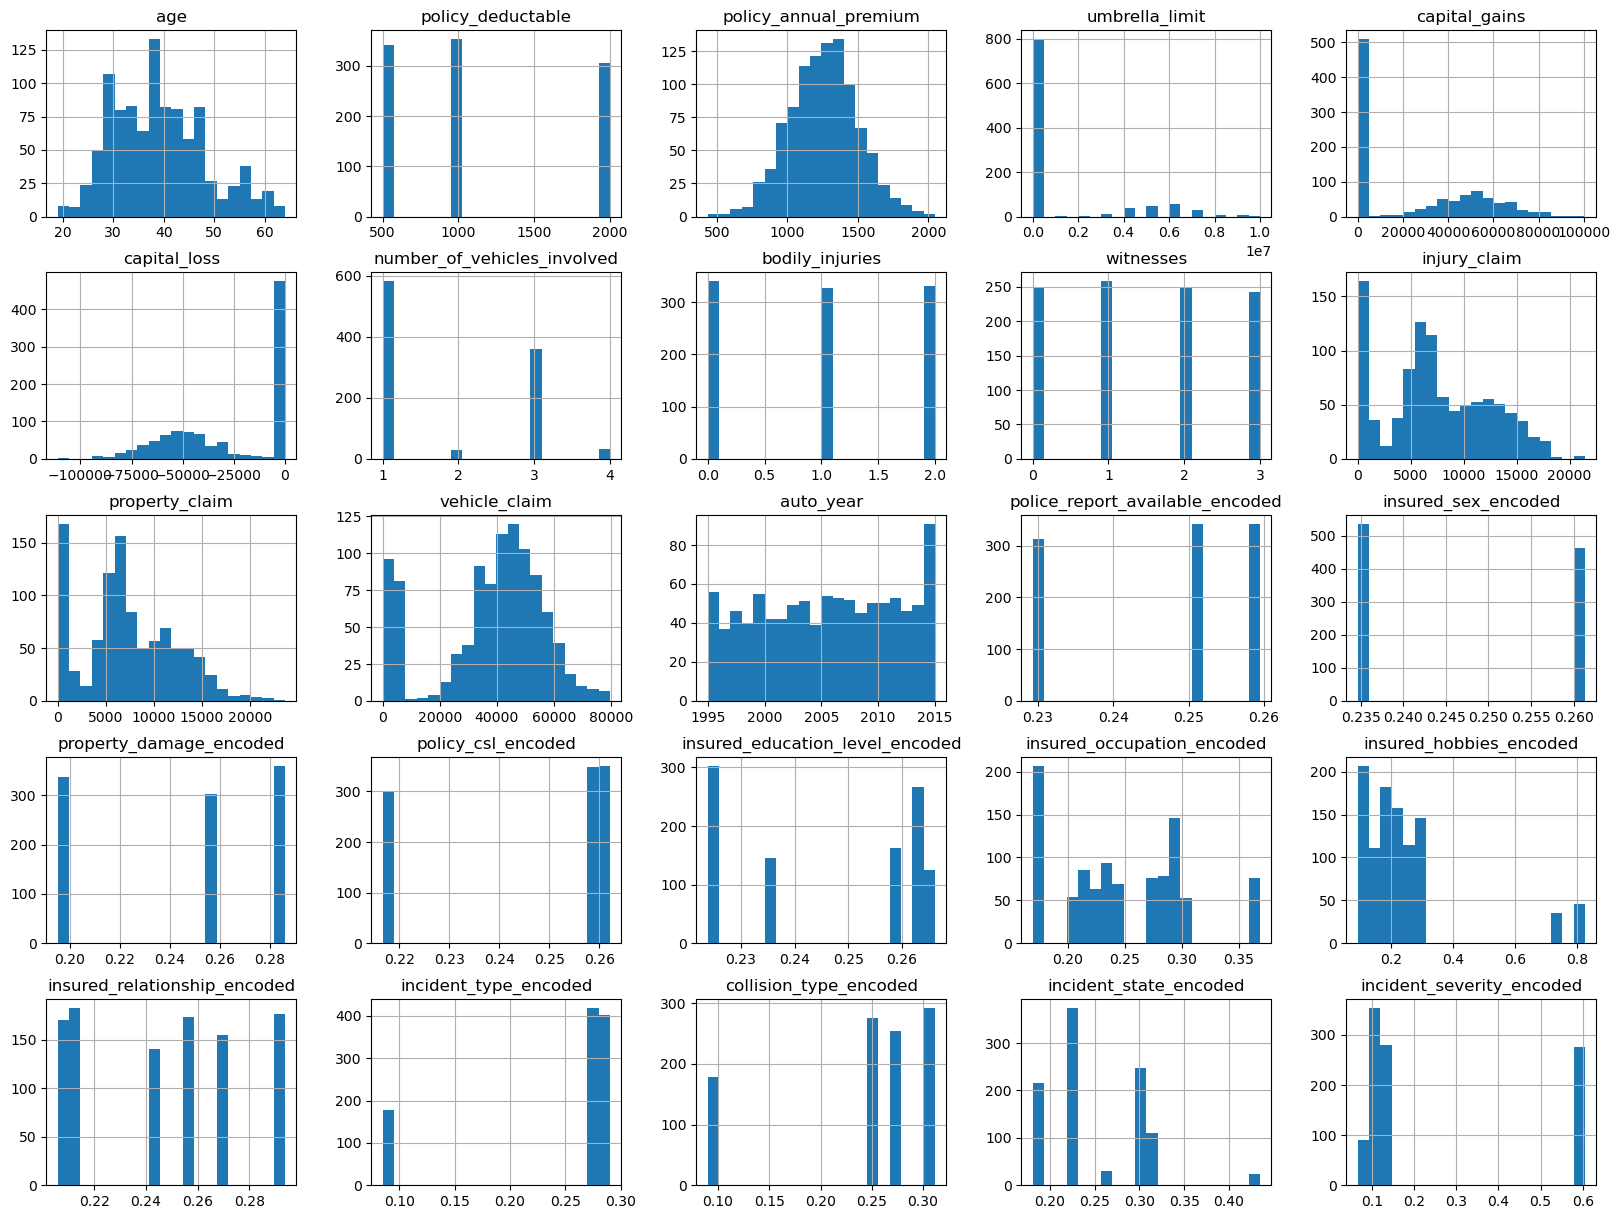

In [298]:
# visualisation distribution of numerical features
numerical_columns = df_copy.select_dtypes(include=['float64', 'int64']).columns
df_copy[numerical_columns].hist(bins=20, figsize=(20, 15))
plt.show()


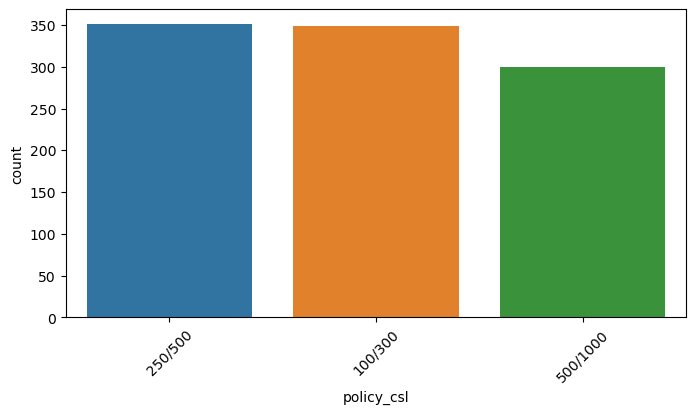

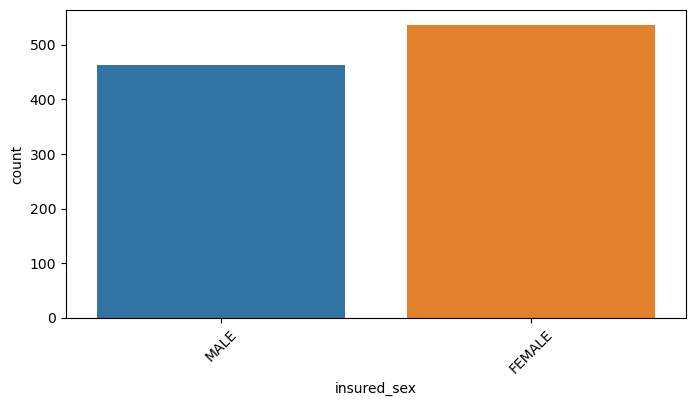

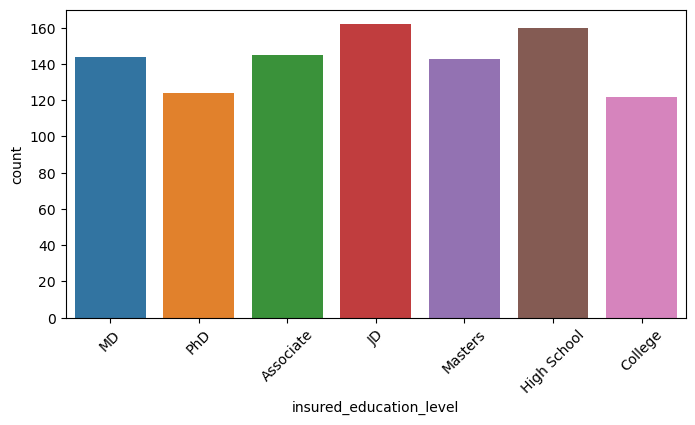

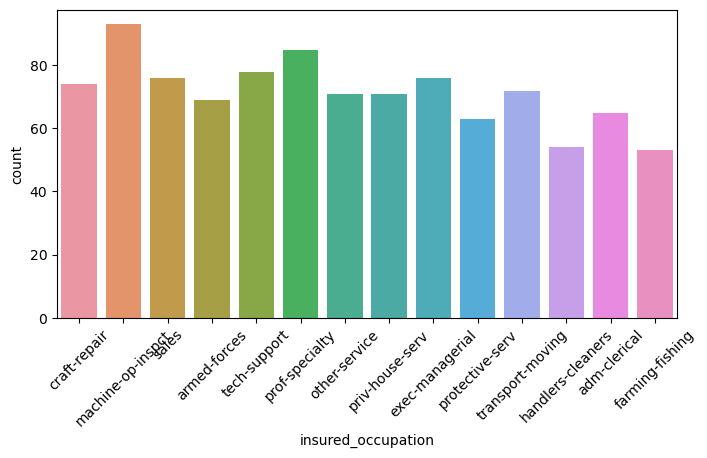

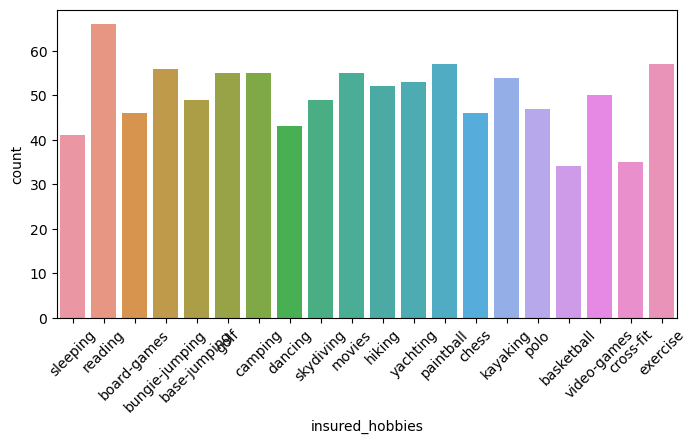

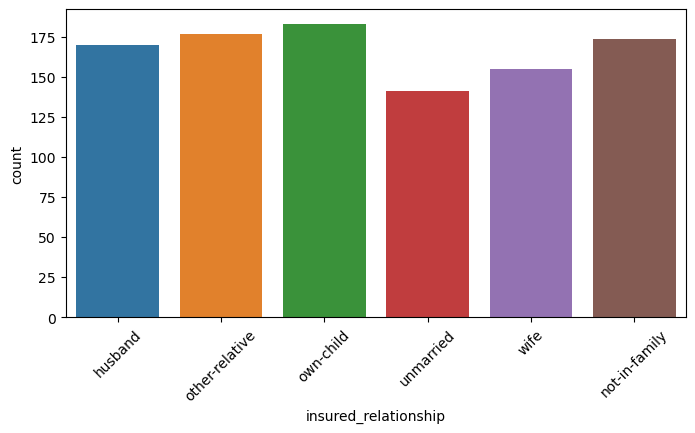

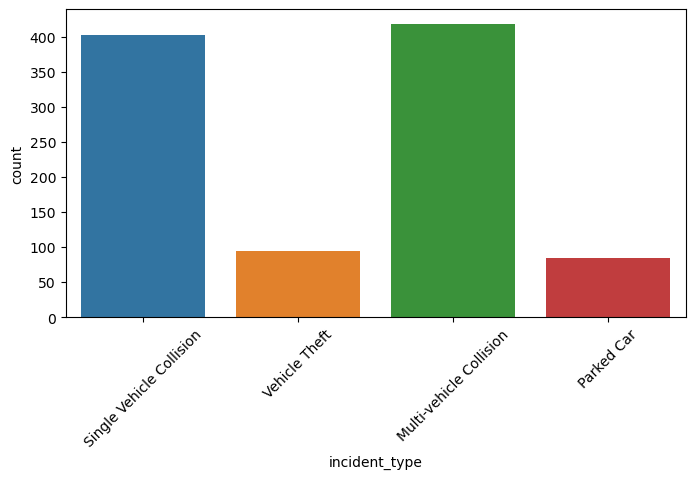

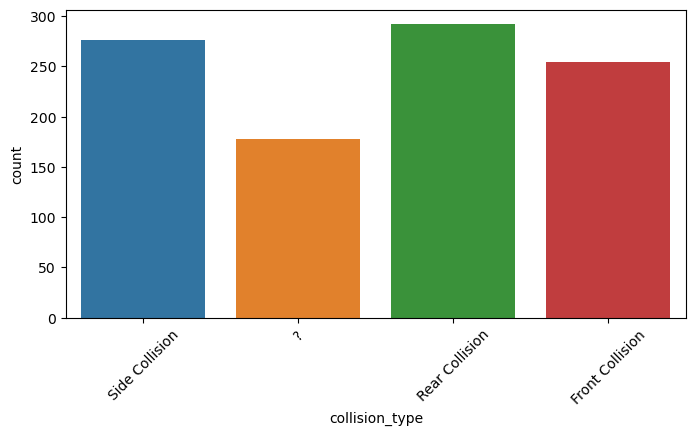

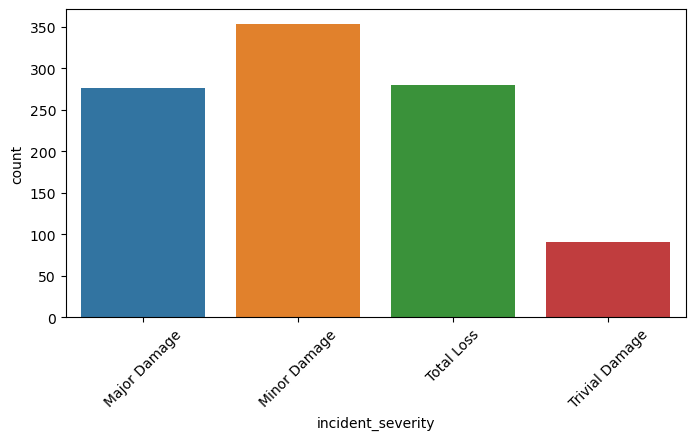

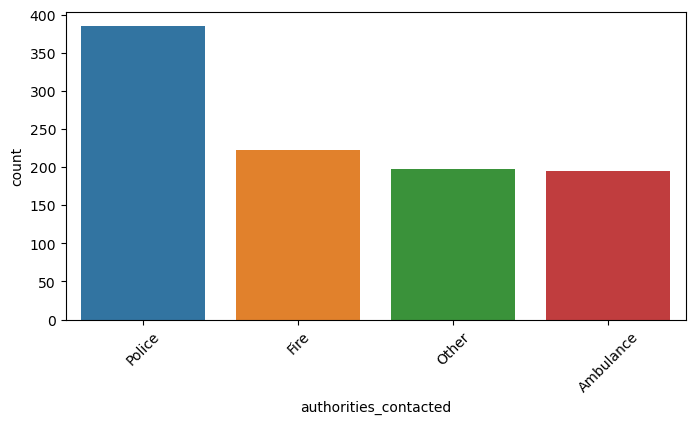

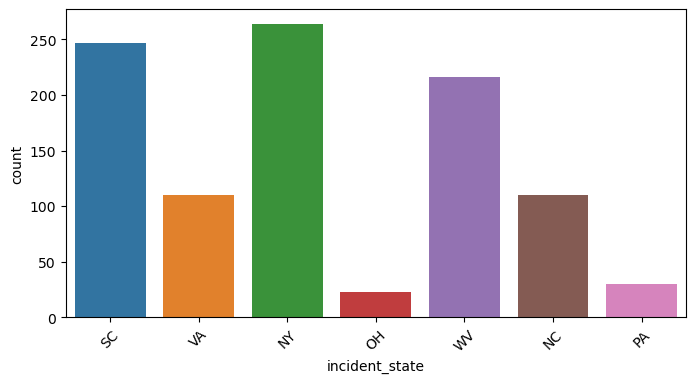

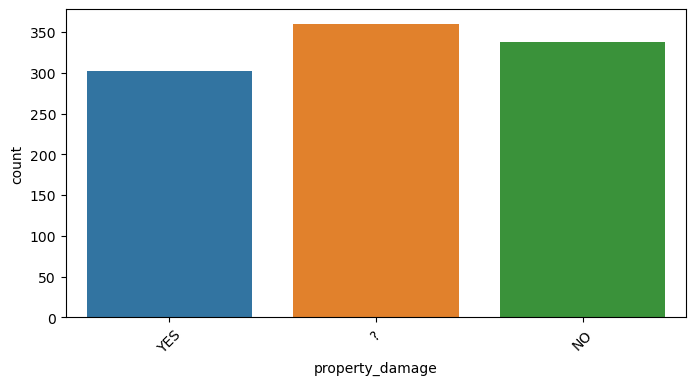

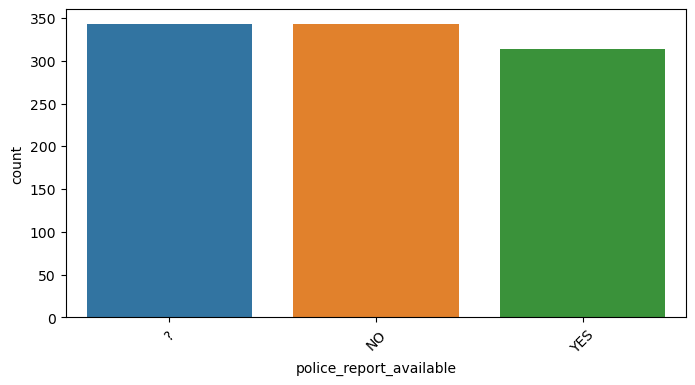

In [299]:
# visualisation distribution of categorical features
categorical_columns = df_copy.select_dtypes(include=['object', 'category']).columns
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_copy, x=col)
    plt.xticks(rotation=45)
    plt.show()


Observation:

Upon further inspection, I noticed that the collision_type, property_damage and police_report_available have unknown data denoted as '?'. When handling missing values, we would not have detected these as missing because they have been inputted as unknown data. However, this is not very helpful for us, so we will replace the '?' data using the same imputation rule used above - replacing with the mode imputation approach.

In [300]:
# replacing '?' with NaN
df_copy['property_damage'] = df_copy['property_damage'].replace('?', np.nan)
df_copy['police_report_available'] = df_copy['police_report_available'].replace('?', np.nan)
df_copy['collision_type'] = df_copy['collision_type'].replace('?', np.nan)

# imputing missing values with the mode 
df_copy['property_damage'].fillna(df_copy['property_damage'].mode()[0], inplace=True)
df_copy['police_report_available'].fillna(df_copy['police_report_available'].mode()[0], inplace=True)
df_copy['collision_type'].fillna(df_copy['collision_type'].mode()[0], inplace=True)

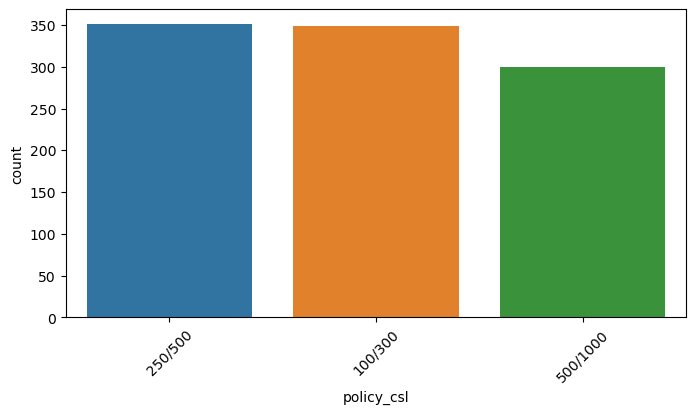

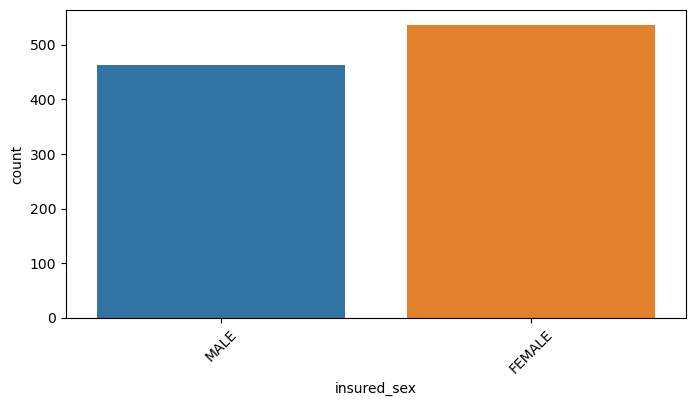

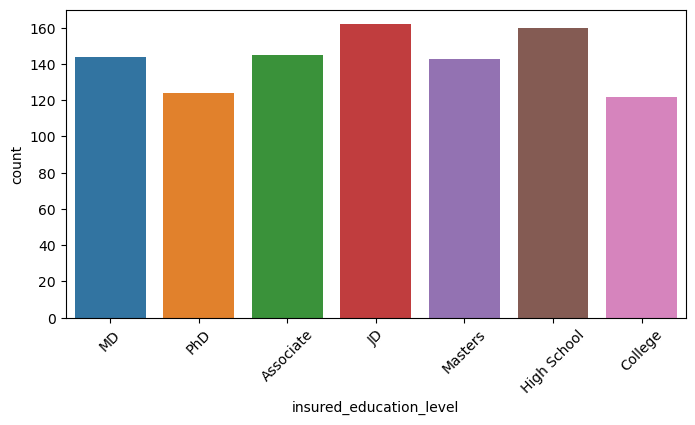

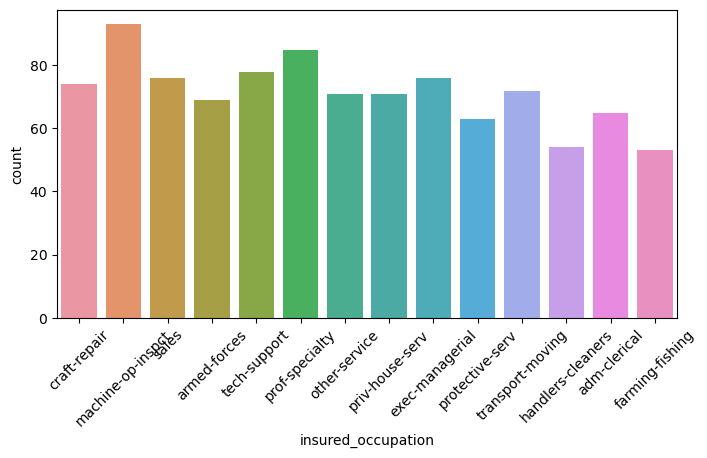

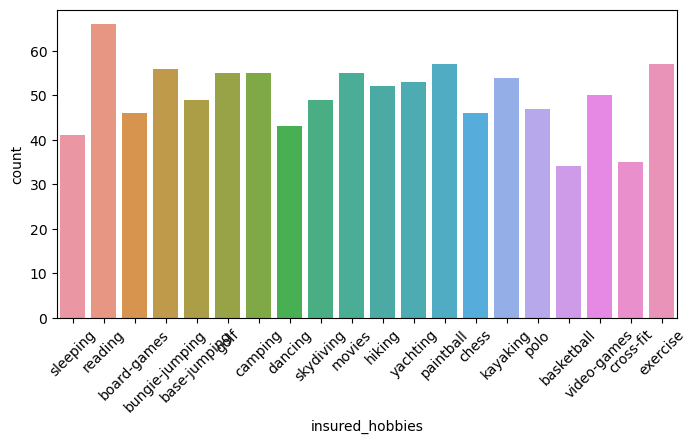

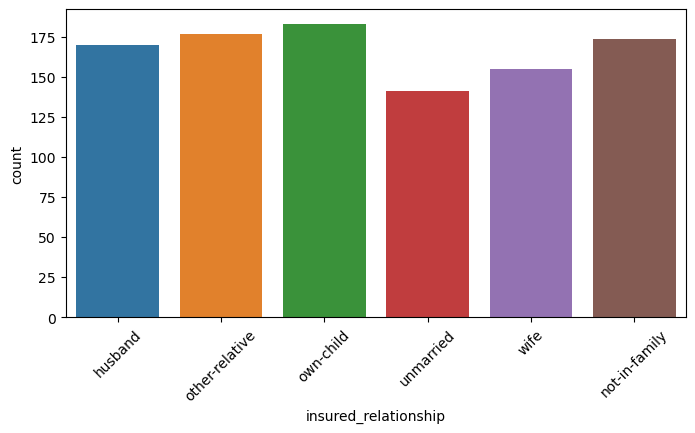

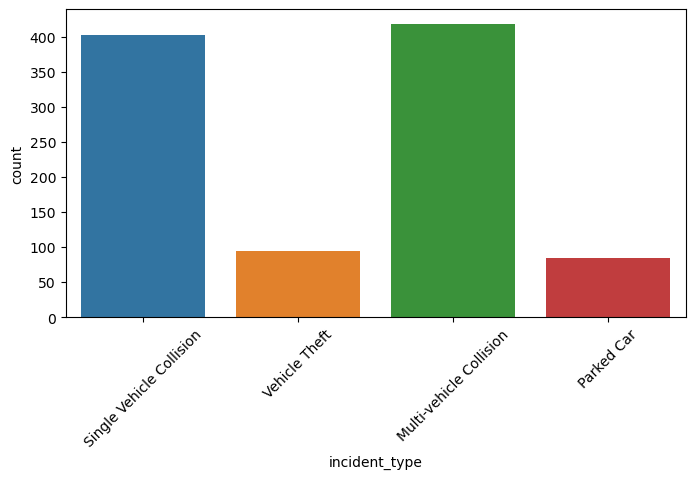

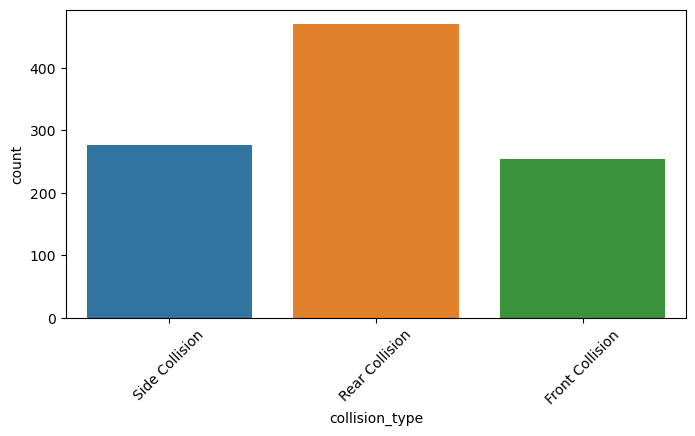

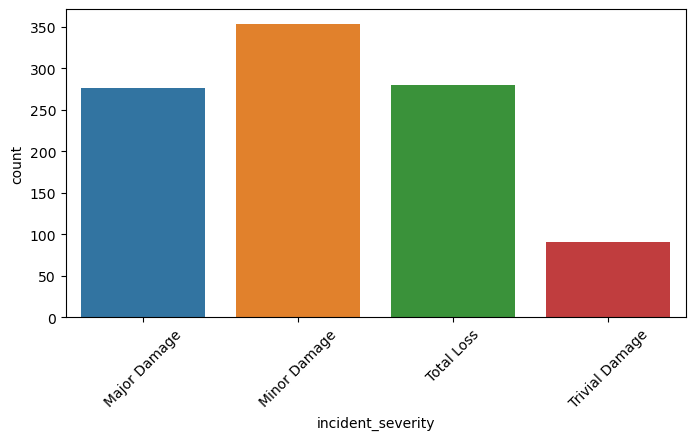

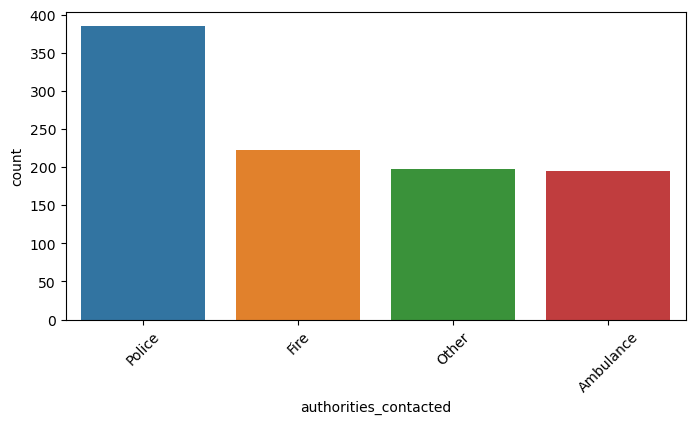

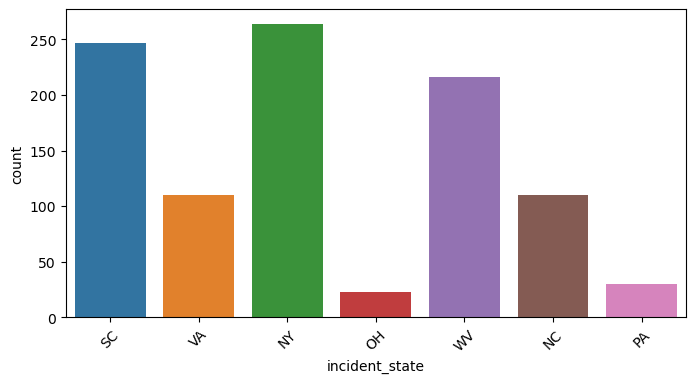

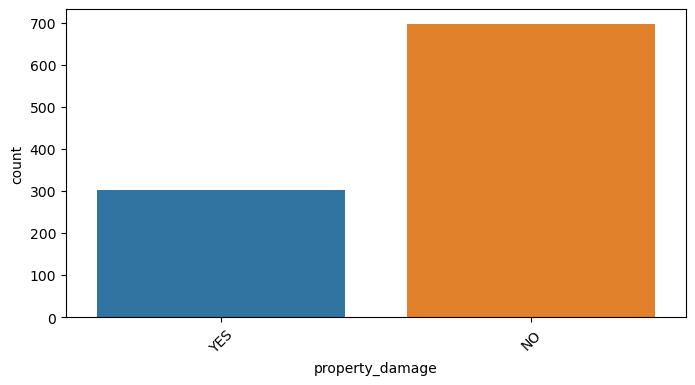

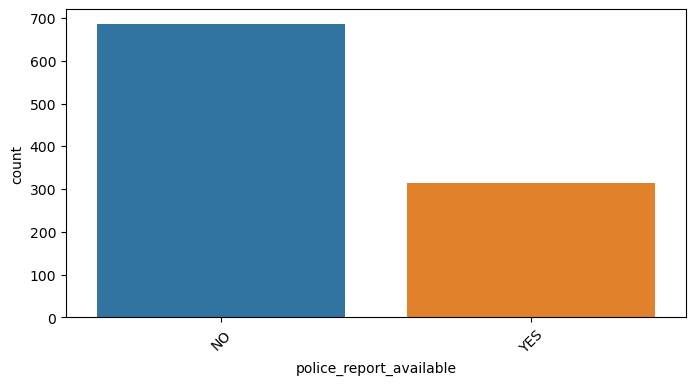

In [301]:
# verifying that the unknown data has been imputed correctly
categorical_columns = df_copy.select_dtypes(include=['object', 'category']).columns
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_copy, x=col)
    plt.xticks(rotation=45)
    plt.show()

#### Step 2:
##### Bivariate Analysis

Next, I will explore bivariate analysis. This involves the examination of the relationship between two variables to understand how they interact or influence each other. It helps identify correlations, trends, and potential dependencies between variables, which can be critical for feature selection and model building. For numerical variables, techniques like scatter plots & correlation coefficients are commonly used to assess the strength and nature of relationships. For categorical variables, tools such as cross-tabulations, contingency tables, and stacked bar charts are used to explore associations. 

For this project, I will run a correlation heat map to understand how the features correlate to each other and the target feature.

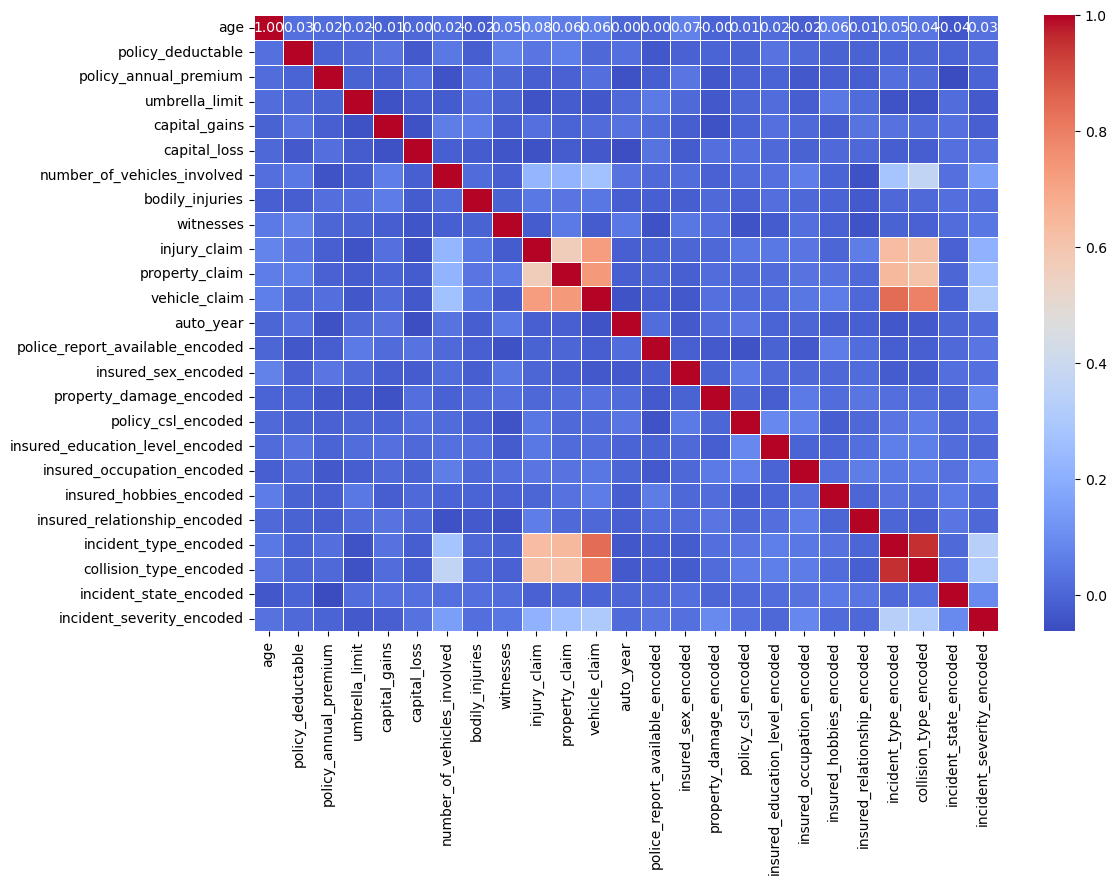

In [302]:
# plotting the correlation heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df_copy[numerical_columns].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()


Observations:


* The variables injury_claim, property_claim, and vehicle_claim show very high correlations with each other. Specifically, vehicle_claim and property_claim, and both have strong correlations with injury_claim. This suggests that these claims are often related and may share common underlying factors (e.g., type of incident or severity).

* incident_type_encoded and collision_type_encoded show an extremely high correlation of 0.951, which indicates that the type of incident (e.g., collision, theft, etc.) is closely related to the type of collision (e.g., rear-end, head-on). This could imply that a specific incident type is strongly associated with certain collision types, which could be useful for model prediction or understanding the data structure.

* number_of_vehicles_involved has a moderate to strong correlation with multiple claims variables, especially injury_claim and vehicle_claim. This suggests that incidents involving more vehicles may lead to higher claims, which could be important when assessing risk or setting premiums based on the number of vehicles involved in an accident.

#### Step 3:
##### Checking for multi-collinearity

I will use pairplots to visualise the multi-collinearity mentioned above to confirm if there is a need to address it

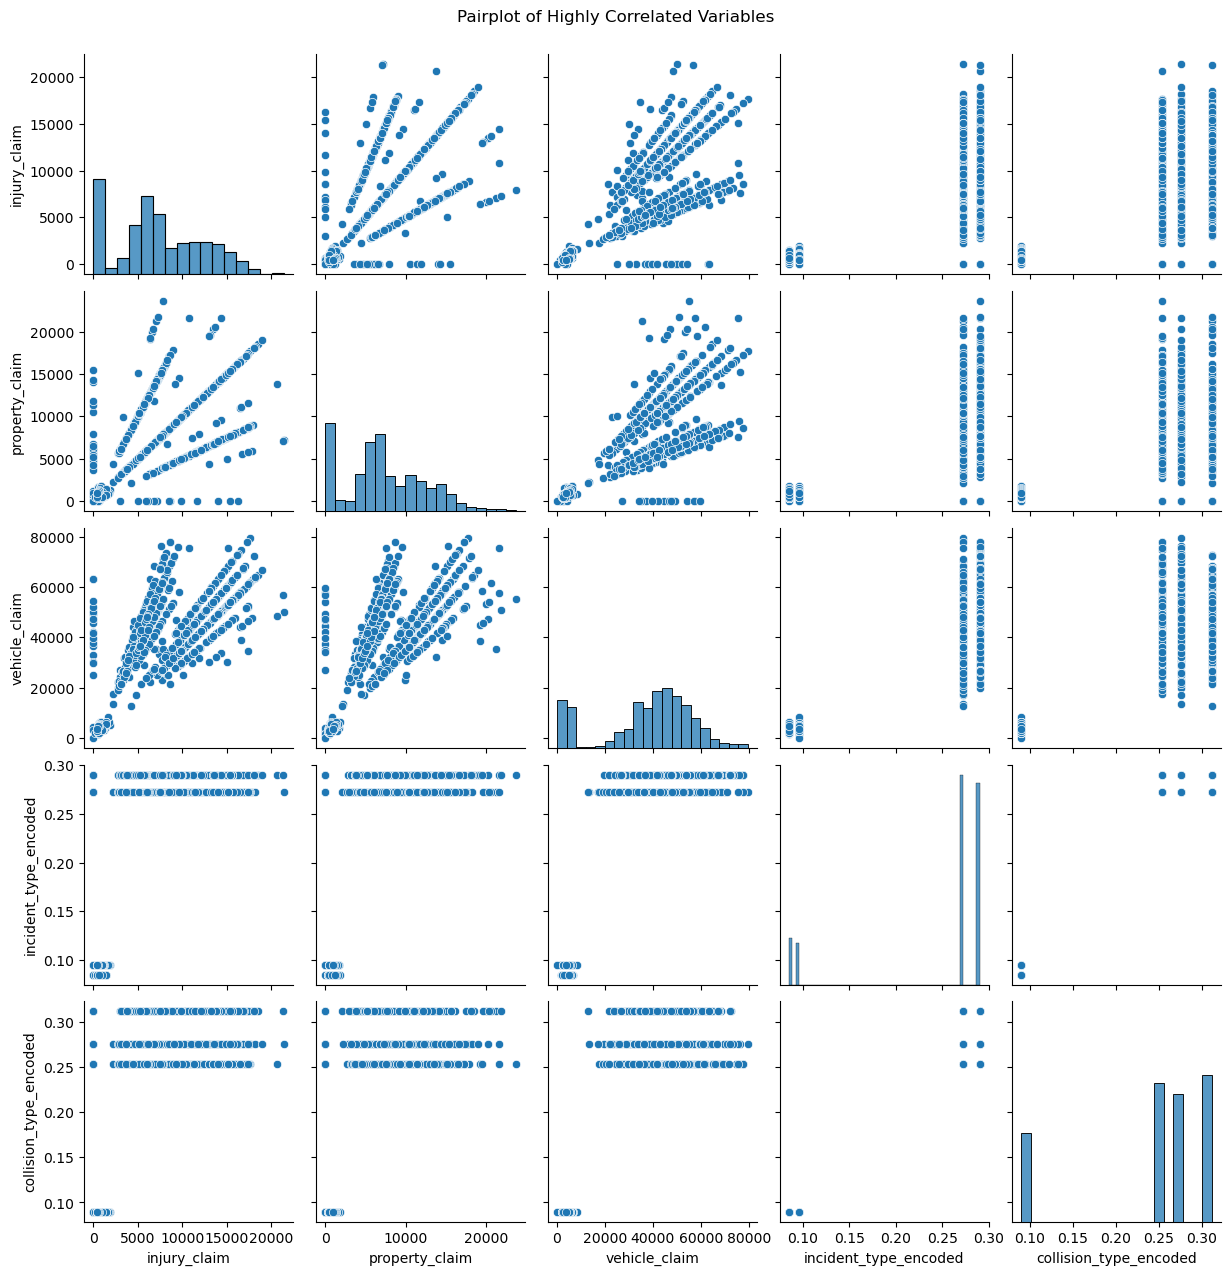

In [303]:
# selecting the columns mentioned above
selected_columns = [
    'injury_claim', 'property_claim', 'vehicle_claim', 
    'incident_type_encoded', 'collision_type_encoded'
]

# creating pairplot to visualize multicollinearity
sns.pairplot(df_copy[selected_columns])
plt.suptitle('Pairplot of Highly Correlated Variables', y=1.02)
plt.show()

Observation:

There seems to be very little multi-collinearity between the impactful features, with the exception of vehicle_claim and propert_claim, which we had already made mention of from the correlation heatmap above. Given that these two are so highly correlated, they might serve a similar role in the predictive modeling, so I might consider removing one of them from the model.

#### Step 4:
##### Checking Class Imbalance 

I will continue by unpacking the fraud_reported column. This will be our target variable for this project, so getting to unpack this is important for our prediction modeling. 

In [304]:
# getting a count of the fraud reported category
fraud_reported = df['fraud_reported'].value_counts()

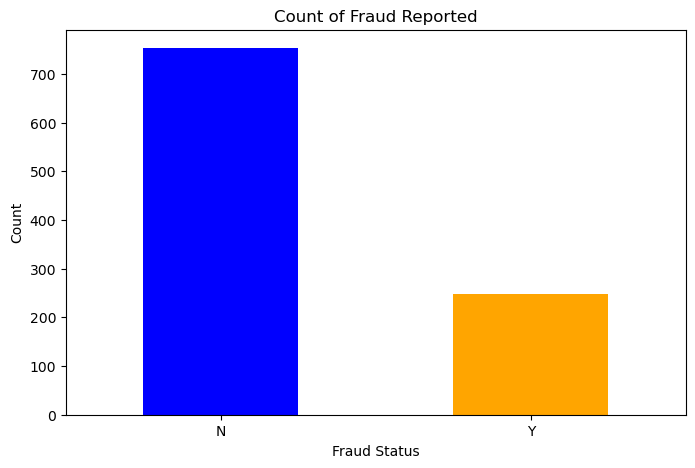

In [305]:
# visualising the count of the target category
plt.figure(figsize=(8, 5))
fraud_reported.plot(kind='bar', color=['blue', 'orange'])
plt.title('Count of Fraud Reported')
plt.xlabel('Fraud Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Observation:

We are noting some class imbalance in the fraud_reported category which can potentially affect the performance of the predictive models. Class imbalance can lead to biased predictions, where models tend to favor the majority class, resulting in poor performance for the minority class. In this section of the project, I will only make note of this. Any decisions to correct this class imbalance will take place in the **Modeling** section of this project. 

#### Step 5:
##### Scaling the data

Next I will scale the data. Scaling the data is the process of normalizing or standardizing features so that they have a consistent range or distribution. This is crucial in predictive modeling, especially for algorithms like linear regression, support vector machines, and k-nearest neighbors, where the model's performance can be sensitive to the scale of the input features. Proper scaling ensures that no single feature dominates the model due to its larger magnitude, improving convergence speed and model accuracy.

In [306]:
# scoling the data in preperation of modeling
scaler = StandardScaler()
df_copy[numerical_columns] = scaler.fit_transform(df_copy[numerical_columns])


#### Step 6:
##### Removing the original categorical columns

This is the part where I remove the original categorical columns to ensure that our dataset only contains numerical data that will be used for modeling. 

In [307]:
# dropping the original columns from the dataframe

# List of original columns that you want to drop (before encoding)
original_columns = ['property_damage', 'police_report_available', 'insured_sex', 'insured_education_level', 
                    'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 
                    'collision_type', 'incident_state', 'incident_severity']

# Drop original columns from the dataframe
df_copy.drop(columns=original_columns, inplace=True)

# Optionally, check that the dataframe no longer contains the original columns
print(df_copy.columns)


Index(['age', 'policy_bind_date', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'capital_gains',
       'capital_loss', 'incident_date', 'authorities_contacted',
       'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year',
       'fraud_reported', 'police_report_available_encoded',
       'insured_sex_encoded', 'property_damage_encoded', 'policy_csl_encoded',
       'insured_education_level_encoded', 'insured_occupation_encoded',
       'insured_hobbies_encoded', 'insured_relationship_encoded',
       'incident_type_encoded', 'collision_type_encoded',
       'incident_state_encoded', 'incident_severity_encoded'],
      dtype='object')


The Exploratory Data Analysis (EDA) phase is crucial in understanding the dataset, uncovering patterns, and preparing the data for predictive modeling. 

In this process, univariate analysis was first performed to examine the distribution, central tendency, and potential outliers of individual features. Next, bivariate analysis, including a correlation heatmap, helped identify relationships between pairs of variables and highlighted areas of potential multicollinearity. This was further explored using pairplots to visually confirm these correlations and assess their impact. 

The class distribution of the target variable was checked for potential imbalance, which could affect model performance and necessitate techniques like resampling. Following this, the data was scaled to ensure that features were on a consistent magnitude, crucial for algorithms sensitive to feature scale. Finally, redundant original categorical columns were removed before encoding to reduce noise and streamline the dataset. 

Overall, this EDA process is essential for ensuring data quality, identifying important features, and setting the stage for building accurate and efficient predictive models.

----
<a id="seven"></a>
## Feature Selection
<a href=#cont>Back to Table of Contents</a>

Feature selection is a crucial step in building machine learning models, where the goal is to identify the most relevant features that contribute to the model's predictive power. By removing irrelevant or redundant features, feature selection helps improve model performance, reduce overfitting, and decrease computational complexity.

In this section, I will performa two step approach of Recursive Feature Elimination (RFE) for feature selection and Principal Component Analysis (PCA) for dimensionality reduction. RFE and PCA provide a two-step approach to optimizing the dataset before model training. RFE ensures that only the most relevant features are retained, while PCA reduces dimensionality, making the data more manageable and helping models perform more efficiently. By applying these techniques, I attempt to improve model accuracy, interpretability, and scalability before moving on to the model training phase.

RFE is a powerful feature selection technique used to identify the most relevant features for a predictive model. RFE works by recursively building a model and removing the least important features based on model performance. The process starts with all features and iteratively eliminates the least significant features, typically using a model (like logistic regression or Random Forest Classifier) to assess feature importance. RFE continues until the optimal set of features is identified.

The key benefit of using RFE for feature selection is that it helps improve model performance by reducing overfitting, improving model interpretability, and speeding up training times. By removing irrelevant or redundant features, RFE helps focus the model on the most important predictors, reducing complexity and allowing the model to generalize better to new data.

After selecting the most important features using RFE, PCA can be applied for dimensionality reduction. PCA transforms the feature space by projecting the original features onto a smaller set of uncorrelated components, capturing the maximum variance in the data. This technique reduces the number of input features while retaining the most important information, making it particularly useful when dealing with high-dimensional data.

The main benefit of PCA is that it simplifies the dataset by reducing the number of features, which can help mitigate the "curse of dimensionality" in machine learning models. It can improve model efficiency, reduce computation time, and sometimes enhance performance by removing noise and focusing on the principal components that drive the most variance in the data.

These approach will help determine the optimal subset of features for further model training and evaluation.

In [308]:
# separating features and target variable

X = df_copy.drop(columns=['fraud_reported']).select_dtypes(include=['number'])
y = df_copy['fraud_reported']  

In [309]:
# splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [310]:
#RFA for initial feature selection

# Initialize the model
model = RandomForestClassifier(random_state=42)

# Initialize RFE with the model, and set the number of features to select (e.g., 10)
rfe = RFE(estimator=model, n_features_to_select=10)  # You can adjust the number of features selected

# Fit RFE to the training data
X_train_rfe = rfe.fit_transform(X_train, y_train)

# Get the selected features
selected_features_rfe = X_train.columns[rfe.support_]
print("Selected Features from RFE:", selected_features_rfe)


Selected Features from RFE: Index(['age', 'policy_annual_premium', 'capital_gains', 'injury_claim',
       'property_claim', 'vehicle_claim', 'auto_year',
       'insured_occupation_encoded', 'insured_hobbies_encoded',
       'incident_severity_encoded'],
      dtype='object')


In [311]:
# dimensionality reduction using PCA

# Standardize the data (RFE has already reduced the feature set)
scaler = StandardScaler()
X_train_rfe_scaled = scaler.fit_transform(X_train_rfe)

# Apply PCA to reduce dimensionality (e.g., retain 95% of variance)
pca = PCA(n_components=0.95)  # Keep 95% variance
X_train_pca = pca.fit_transform(X_train_rfe_scaled)

# Check the number of components selected
print(f"Number of components selected by PCA: {X_train_pca.shape[1]}")


Number of components selected by PCA: 9


Now, I'll apply Lasso regression to the data. 

The RFE process selected 10 key features, including variables related to claims, premiums, and demographic factors, which are deemed most relevant for the predictive model. Following this,PCA was applied, reducing the dimensionality of the data to 9 principal components, and capturing the most important variance while simplifying the feature space for more efficient model training.

---
<a id="eight"></a>
## Modeling
<a href=#cont>Back to Table of Contents</a>

With the data prepared through extensive EDA, feature selection using RFE, and dimensionality reduction via PCA, we are now ready to move on to the modeling phase. The results from RFE provide a refined set of the most relevant features, ensuring that only the key predictors are used in model training, reducing complexity and potential overfitting. Meanwhile, PCA's dimensionality reduction simplifies the feature space by retaining the most important components, further optimizing model performance and efficiency. Using these processed features, we can now proceed to train and evaluate predictive models with greater accuracy and speed.

In this project, I will run three predictive models and choose the best one based on accuracy, precision and recall. The models are: Logistic Regression, Random Forest Classifier and XGBoost. 

In [312]:
# applying RFE selected features
selected_features_rfe = ['age', 'policy_annual_premium', 'capital_gains', 'injury_claim',
                        'property_claim', 'vehicle_claim', 'auto_year',
                        'insured_occupation_encoded', 'insured_hobbies_encoded',
                        'incident_severity_encoded']


In [313]:
# using these features for both training & testing data sets
# Subset the training and test sets using the selected features from RFE
X_train_rfe_selected = X_train[selected_features_rfe]
X_test_rfe_selected = X_test[selected_features_rfe]


In [314]:
# applying PCA
# Standardize the data (scaler was applied earlier)
X_train_rfe_scaled = scaler.fit_transform(X_train_rfe_selected)
X_test_rfe_scaled = scaler.transform(X_test_rfe_selected)

# applyinhg PCA to reduce dimensionality to 9 components
X_train_pca = pca.fit_transform(X_train_rfe_scaled)
X_test_pca = pca.transform(X_test_rfe_scaled)

print("Shape of training data after PCA:", X_train_pca.shape)
print("Shape of test data after PCA:", X_test_pca.shape)


Shape of training data after PCA: (700, 9)
Shape of test data after PCA: (300, 9)


Training my models

In [315]:
# logist regression

# Initialize the Logistic Regression model
logreg = LogisticRegression(random_state=42)

# Train the model
logreg.fit(X_train_pca, y_train)

# Predict on the test set
y_pred_logreg = logreg.predict(X_test_pca)

# Evaluate the model
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))


Logistic Regression Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       220
           1       0.67      0.72      0.70        80

    accuracy                           0.83       300
   macro avg       0.79      0.80      0.79       300
weighted avg       0.84      0.83      0.84       300



In [316]:
# random forest classifier

# Initialize the Random Forest Classifier model
rf = RandomForestClassifier(random_state=42)

# Train the model
rf.fit(X_train_pca, y_train)

# Predict on the test set
y_pred_rf = rf.predict(X_test_pca)

# Evaluate the model
print("Random Forest Classifier Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Classifier Accuracy: 0.8033333333333333
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       220
           1       0.65      0.56      0.60        80

    accuracy                           0.80       300
   macro avg       0.75      0.73      0.74       300
weighted avg       0.80      0.80      0.80       300



In [317]:
# XGBoost

# Initialize the XGBoost model
xgb = XGBClassifier(random_state=42)

# Train the model
xgb.fit(X_train_pca, y_train)

# Predict on the test set
y_pred_xgb = xgb.predict(X_test_pca)

# Evaluate the model
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.81
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       220
           1       0.66      0.60      0.63        80

    accuracy                           0.81       300
   macro avg       0.76      0.74      0.75       300
weighted avg       0.81      0.81      0.81       300



In the next phase of the project, I will evaluate the best model out of the three above

---
<a id="nine"></a>
## Evaluation and Validation
<a href=#cont>Back to Table of Contents</a>

#### Key Metrics to Consider: 

*1. Precision:*
Class 0 (Non-fraud):
* Logistic Regression has the highest precision (0.90), meaning it is very good at correctly predicting non-fraudulent claims.
* Random Forest and XGBoost have similar precision scores (0.85 and 0.86, respectively).
Class 1 (Fraudulent): Here, the models struggle a bit more.
* Logistic Regression has the highest precision (0.67), meaning it correctly identifies fraudulent claims about 67% of the time.
* Random Forest and XGBoost both perform similarly here as well, with precision around 0.65–0.66.

*2. Recall:*
Class 0 (Non-fraud):
* Random Forest performs the best in terms of recall (0.89), meaning it catches 89% of non-fraudulent claims.
* Logistic Regression follows with a recall of 0.87, and XGBoost is close with 0.89.
Class 1 (Fraudulent):
* Logistic Regression has the best recall for fraudulent claims (0.72). It identifies 72% of fraudulent claims correctly.
* XGBoost and Random Forest both have a similar recall (0.56–0.60), meaning they are missing a significant number of fraudulent claims.

*3. F1-Score (Harmonic Mean of Precision and Recall):*
Class 1 (Fraudulent):
* Logistic Regression again stands out with an F1-score of 0.70, which is the highest for fraudulent claims.
* XGBoost follows with 0.63, and Random Forest has the lowest F1-score for fraudulent claims (0.60).

    Overall Model Comparison (Weighted F1):
* Logistic Regression has the highest weighted F1-score (0.84), which balances precision and recall across both classes.
* XGBoost and Random Forest are similar in terms of weighted F1 (0.81 and 0.80, respectively).

    Class 1 (Fraudulent):
* Logistic Regression again stands out with an F1-score of 0.70, which is the highest for fraudulent claims.
* XGBoost follows with 0.63, and Random Forest has the lowest F1-score for fraudulent claims (0.60).

    Overall Model Comparison (Weighted F1):
* Logistic Regression has the highest weighted F1-score (0.84), which balances precision and recall across both classes.
* XGBoost and Random Forest are similar in terms of weighted F1 (0.81 and 0.80, respectively).

#### Conclusion:

Best Model for Predicting Fraudulent Claims: Logistic Regression

* Recall for Class 1 (Fraudulent Claims): Logistic Regression identifies 72% of fraudulent claims, which is better than both Random Forest (56%) and XGBoost (60%).
* F1-Score for Class 1: Logistic Regression also has the highest F1-score for fraudulent claims (0.70), meaning it strikes a good balance between precision and recall for fraudulent claims.
* Weighted Average F1: Logistic Regression also has the highest overall F1-score (0.84), indicating it performs the best when considering both classes.

Trade-offs:
Random Forest and XGBoost both perform better in terms of precision for non-fraudulent claims (Class 0), but they miss a substantial number of fraudulent claims due to lower recall.

However, Logistic Regression seems to be the best model in terms of handling the imbalanced nature of the data. It does a better job of identifying fraudulent claims, which is crucial for fraud detection. The downside is that it might flag more non-fraudulent claims as fraudulent (lower precision), but this is a common trade-off in fraud detection where missing a fraudulent claim (false negative) is more costly than flagging a non-fraudulent one as fraudulent (false positive).

---
<a id="ten"></a>
## Final Model
<a href=#cont>Back to Table of Contents</a>

Once we've identified Logistic Regression as the best model for detecting fraudulent insurance claims, we can use GridSearchCV to fine-tune the model's hyperparameters and optimize its performance. GridSearchCV is a technique that performs an exhaustive search over a specified parameter grid, evaluating all possible combinations of hyperparameters to find the best set based on model performance. By using cross-validation, GridSearchCV ensures that the chosen hyperparameters generalize well to unseen data, helping improve the accuracy and robustness of the Logistic Regression model in predicting fraudulent claims.

In [318]:
# finding the best parameters using gridsearchcv

# Define the parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l2'],  # Regularization type
    'solver': ['liblinear'],  # Solver
    'max_iter': [100, 200, 300]  # Max iterations
}

# Initialize the Logistic Regression model
log_reg = LogisticRegression()

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the model with grid search
grid_search.fit(X_train_pca, y_train)

# Get the best parameters from GridSearchCV
best_params = grid_search.best_params_

# Print the best parameters
print(f"Best hyperparameters: {best_params}")


Best hyperparameters: {'C': 0.01, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}


In [319]:
# training the model using the best parameters
# Initialize the model with the best hyperparameters
best_log_reg = grid_search.best_estimator_

# Train the model
best_log_reg.fit(X_train_pca, y_train)

# Make predictions on the test set
y_pred = best_log_reg.predict(X_test_pca)

# Evaluate the model's performance

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy}")

# Classification Report
print(classification_report(y_test, y_pred))


Logistic Regression Accuracy: 0.8433333333333334
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       220
           1       0.68      0.79      0.73        80

    accuracy                           0.84       300
   macro avg       0.80      0.83      0.81       300
weighted avg       0.85      0.84      0.85       300



#### Key Performance Changes (after tuning model):

*Accuracy:*

Before fine-tuning: 0.83
After fine-tuning: 0.8433
Change: The accuracy increased by 1 percentage point (from 83% to 84.33%), which indicates a slight improvement in the model's overall performance.

*Precision (Class 1 - Fraudulent Claims):*

Before fine-tuning: 0.67
After fine-tuning: 0.68
Change: Precision for fraudulent claims improved from 0.67 to 0.69. This means that out of all the instances the model predicted as fraudulent (Class 1), a higher proportion were actually fraudulent after fine-tuning. This indicates a reduction in false positives, which is important for minimizing unnecessary investigations in fraud detection.

*Recall (Class 1 - Fraudulent Claims):*

Before fine-tuning: 0.72
After fine-tuning: 0.79
Change: Recall for fraudulent claims significantly improved from 0.72 to 0.79. This means the model is better at identifying fraudulent claims after fine-tuning. It is catching more fraudulent claims (fewer false negatives), which is crucial in fraud detection where missing fraudulent claims could be costly.


*F1-Score (Class 1 - Fraudulent Claims):*

Before fine-tuning: 0.70
After fine-tuning: 0.73
Change: The F1-score for fraudulent claims increased from 0.70 to 0.73. The F1-score is the harmonic mean of precision and recall, and the improvement indicates a better balance between precision and recall. This is good news because it suggests that the model is not only catching more fraudulent claims but is also doing so without significantly increasing false positives.

*Precision (Class 0 - Non-Fraudulent Claims):*

Before fine-tuning: 0.90
After fine-tuning: 0.92
Change: Precision for non-fraudulent claims (Class 0) improved from 0.90 to 0.92. This indicates that, after fine-tuning, a higher proportion of the instances predicted as non-fraudulent (Class 0) were actually non-fraudulent, reflecting a reduction in false positives for the non-fraudulent class.

*Recall (Class 0 - Non-Fraudulent Claims):*

Before fine-tuning: 0.87
After fine-tuning: 0.86
Change: Recall for non-fraudulent claims decreased slightly from 0.87 to 0.86. This means the model is identifying slightly fewer non-fraudulent claims correctly after fine-tuning, which may result in a small increase in false negatives.

*Weighted Average:*

The weighted average F1-score, precision, and recall all improved after fine-tuning, reflecting the overall improvement in the model's performance across both classes (fraudulent and non-fraudulent claims). These small improvements in the weighted averages suggest that the fine-tuning had a positive impact on the model's overall performance.

#### Key Insights:
*There is slight but meaningful improvement:*

The accuracy improved slightly from 83.33% to 84.33%. While this may seem like a small increase, even a modest accuracy improvement can be meaningful in a classification task like fraud detection. Small gains in accuracy often reflect that the model is better at distinguishing between the two classes (fraudulent and non-fraudulent claims).

Improved Recall for Fraudulent Claims:


The recall for fraudulent claims (Class 1) improved significantly from 0.72 to 0.79. Recall measures the model's ability to correctly identify fraudulent claims. This increase means that the model is now catching more fraudulent claims, which is particularly important in fraud detection to minimize false negatives (missing fraudulent claims).

Balanced Precision-Recall Tradeoff:

The F1-score for fraudulent claims also improved from 0.70 to 0.73. The F1-score reflects the balance between precision and recall. This improvement suggests that the model is both catching more fraudulent claims (higher recall) and maintaining a reasonable level of precision. Fine-tuning helped improve the balance, ensuring that the model is better at identifying fraud while not overly increasing false positives.

Slight Decrease in Recall for Non-Fraudulent Claims::

The performance for non-fraudulent claims (Class 0) remained stable overall but saw a slight decrease in recall, from 0.87 to 0.86. This indicates that the model is now slightly less effective at correctly identifying non-fraudulent claims, resulting in a small increase in false negatives (non-fraudulent claims misclassified as fraudulent).

Precision for Fraudulent Claims:

Although precision for fraudulent claims improved from 0.67 to 0.68, it is still lower than recall, meaning the model still tends to misclassify some non-fraudulent claims as fraudulent (false positives). This trade-off is typical in fraud detection tasks, where recall is often prioritized to catch as many fraudulent claims as possible, even if it means accepting more false positives. Depending on the business context, further fine-tuning may be necessary to optimize precision or recall.

#### Conclusion:
The model has improved after fine-tuning, particularly in terms of recall and F1-score for fraudulent claims. While the changes are not drastic, they are meaningful in the context of fraud detection, where detecting more fraudulent claims (higher recall) is often the top priority. The precision for fraudulent claims also increased, meaning fewer non-fraudulent claims are being flagged as fraudulent.

---
<a id="eleven"></a>
## Extracting Data for PowerBI Visualisation
<a href=#cont>Back to Table of Contents</a>

In [320]:
# Convert y_test and y_pred to Pandas Series if they are not already
y_test = pd.Series(y_test)
y_pred = pd.Series(y_pred)

# Reset index for proper alignment
X_test_pca_df.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)  # Reset index for y_test
y_pred.reset_index(drop=True, inplace=True)  # Reset index for y_pred


In [321]:
# Extracting model predictions

# Convert PCA-transformed test data to DataFrame
pca_predictions_df = pd.DataFrame(X_test_pca)  # X_test_pca is the data after PCA transformation

# Add actual and predicted values
pca_predictions_df['Actual_Fraud'] = y_test  # Actual values (ground truth)
pca_predictions_df['Predicted_Fraud'] = y_pred  # Predicted values

# Get predicted probabilities for the positive class (class 1)
probabilities = best_log_reg.predict_proba(X_test_pca)[:, 1]  # Extracting the probability for class 1

# Check the length of probabilities to make sure it matches the number of rows
print(len(probabilities))  # Should print 300

# Add predicted probabilities to the DataFrame
pca_predictions_df['Predicted_Probability'] = probabilities

# Save to CSV for Power BI
pca_predictions_df.to_csv('pca_model_predictions.csv', index=False)


300


In [322]:

# Make predictions using the best model (best_log_reg)
y_pred = best_log_reg.predict(X_test_pca)  # Predict using the best model on the PCA-transformed test data

# Defining your evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, best_log_reg.predict_proba(X_test_pca)[:, 1])  # Using probabilities for ROC AUC

# Extracting model evaluation metrics
metrics = {
    'Model': ['Model with PCA'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1],
    'ROC AUC': [roc_auc]
}

# Creating a DataFrame for the evaluation metrics
evaluation_metrics_df = pd.DataFrame(metrics)

# Save to CSV for Power BI
evaluation_metrics_df.to_csv('evaluation_metrics.csv', index=False)


In [323]:


# --- Logistic Regression Model ---
# Train the model
best_log_reg.fit(X_train_pca, y_train)

# Make predictions on the test set
y_pred_log_reg = best_log_reg.predict(X_test_pca)

# Evaluate the model's performance (Logistic Regression)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
roc_auc_log_reg = roc_auc_score(y_test, best_log_reg.predict_proba(X_test_pca)[:, 1])

# --- Random Forest Model ---
# Initialize the Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Train the model
rf.fit(X_train_pca, y_train)

# Make predictions on the test set
y_pred_rf = rf.predict(X_test_pca)

# Evaluate the model's performance (Random Forest)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test_pca)[:, 1])

# --- XGBoost Model ---
# Initialize the XGBoost Classifier
xgb = XGBClassifier(random_state=42)

# Train the model
xgb.fit(X_train_pca, y_train)

# Make predictions on the test set
y_pred_xgb = xgb.predict(X_test_pca)

# Evaluate the model's performance (XGBoost)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, xgb.predict_proba(X_test_pca)[:, 1])

# --- Store all the metrics for the three models ---
metrics = {
    'Model': ['Logistic Regression (PCA)', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_log_reg, accuracy_rf, accuracy_xgb],
    'Precision': [precision_log_reg, precision_rf, precision_xgb],
    'Recall': [recall_log_reg, recall_rf, recall_xgb],
    'F1 Score': [f1_log_reg, f1_rf, f1_xgb],
    'ROC AUC': [roc_auc_log_reg, roc_auc_rf, roc_auc_xgb]
}

# --- Create a DataFrame for the evaluation metrics ---
evaluation_metrics_df = pd.DataFrame(metrics)

# --- Save the evaluation metrics to a CSV for Power BI ---
evaluation_metrics_df.to_csv('full_evaluation_metrics.csv', index=False)

# --- Display the evaluation metrics ---
print(evaluation_metrics_df)


                       Model  Accuracy  Precision  Recall  F1 Score   ROC AUC
0  Logistic Regression (PCA)  0.843333   0.677419  0.7875  0.728324  0.867670
1              Random Forest  0.803333   0.652174  0.5625  0.604027  0.854972
2                    XGBoost  0.810000   0.657534  0.6000  0.627451  0.838523


In [324]:
# extracting the confusion matrix

# Make predictions using the best model (best_log_reg)
y_pred = best_log_reg.predict(X_test_pca)  # Predict using the best model on the PCA-transformed test data

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert the confusion matrix to a DataFrame for better visualization
cm_df = pd.DataFrame(cm, columns=['Predicted_Non_Fraud', 'Predicted_Fraud'], index=['Actual_Non_Fraud', 'Actual_Fraud'])

# Save to CSV
cm_df.to_csv('confusion_matrix.csv', index=True)


In [325]:
# extracting ROC curve and Precision-Recall curve

# Calculate ROC curve data
fpr, tpr, thresholds = roc_curve(y_test, best_log_reg.predict_proba(X_test_pca)[:, 1])

# Create a DataFrame with the ROC curve data
roc_curve_df = pd.DataFrame({
    'False_Positive_Rate': fpr,
    'True_Positive_Rate': tpr,
    'Threshold': thresholds
})

# Save the ROC curve data to CSV
roc_curve_df.to_csv('roc_curve.csv', index=False)

In [326]:
# joining the test dataset with predictions & actuals

# Assuming X_test_pca, y_test, and y_pred are already defined
# and best_log_reg is your trained Logistic Regression model

# Convert PCA-transformed test data to DataFrame
pca_predictions_df = pd.DataFrame(X_test_pca)  # X_test_pca is the data after PCA transformation

# Add actual and predicted values
pca_predictions_df['Actual_Fraud'] = y_test  # Actual values (ground truth)
pca_predictions_df['Predicted_Fraud'] = y_pred  # Predicted values

# Get predicted probabilities for the positive class (class 1)
probabilities = best_log_reg.predict_proba(X_test_pca)[:, 1]  # Extracting the probability for class 1

# Check the length of probabilities to make sure it matches the number of rows
print(len(probabilities))  # Should print 300

# Add predicted probabilities to the DataFrame
pca_predictions_df['Predicted_Probability'] = probabilities


# Save to CSV for Power BI
pca_predictions_df.to_csv('pca_model_predictions.csv', index=False)


300


In [327]:
# Convert PCA-transformed test data to DataFrame
pca_predictions_df = pd.DataFrame(X_test_pca)  # X_test_pca is the data after PCA transformation

# Reset index of X_test_pca_df to avoid misalignment
pca_predictions_df.reset_index(drop=True, inplace=True)

# Convert actual fraud values and predicted values to DataFrames
predictions_df = pd.DataFrame({
    'Actual_Fraud': y_test,
    'Predicted_Fraud': y_pred
})

# Check if lengths of all DataFrames are equal
print(len(pca_predictions_df), len(predictions_df))  # Should print the same length for both

# Merge the PCA data with the predictions (make sure y_test and y_pred are aligned)
final_predictions_df = pd.concat([pca_predictions_df, predictions_df], axis=1)

# Check for missing values in the 'Actual_Fraud' column
print(final_predictions_df['Actual_Fraud'].isnull().sum())  # Check for any missing values

# Add predicted probabilities for the positive class (class 1)
probabilities = best_log_reg.predict_proba(X_test_pca)[:, 1]  # Extracting the probability for class 1

# Check the length of probabilities to make sure it matches the number of rows
print(len(probabilities))  # Should print 300

# Add predicted probabilities to the DataFrame
final_predictions_df['Predicted_Probability'] = probabilities

# Save to CSV for Power BI
final_predictions_df.to_csv('pca_model_predictions.csv', index=False)


300 300
0
300


In [328]:

# Convert PCA-transformed features to a DataFrame and assign column names
X_test_pca_df = pd.DataFrame(X_test_pca)

# Convert actual fraud values and predicted values to DataFrames
predictions_df = pd.DataFrame({
    'Actual_Fraud': y_test,
    'Predicted_Fraud': y_pred
})

# Merge the PCA data with the predictions (make sure y_test and y_pred are aligned)
final_predictions_df = pd.concat([X_test_pca_df, predictions_df], axis=1)

# Check for missing values in the 'Actual_Fraud' column
print(final_predictions_df['Actual_Fraud'].isnull().sum())  # Check for any missing values

# Save the final_predictions_df to a CSV file for Power BI
final_predictions_df.to_csv('final_predictions.csv', index=False)



0


In [329]:
# extracting PCA variance
explained_variance_ratio = pca.explained_variance_ratio_

# creating a dataframe for variance explianed
pca_variance_df = pd.DataFrame({
    'Principal_Component': [f'PC{i+1}' for i in range(len(explained_variance_ratio))],
    'Variance_Explained': explained_variance_ratio
})

# exporting it to csv
pca_variance_df.to_csv('pca_variance_explained.csv', index=False)


In [330]:
# exporting original dataframe to csv
df_copy.to_csv('manipulated_claims_data.csv', index=False)

In [331]:
df.to_csv('original_claims_data.csv', index=False)

In [332]:
# calculating precision & recall thresholds




precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# Create DataFrame with Precision, Recall, and Thresholds
pr_df = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precision[:-1],  # Precision has one extra value, so we discard the last one
    'Recall': recall[:-1]         # Recall also has one extra value
})

# Save the DataFrame to a CSV file for import into Power BI
pr_df.to_csv('precision_recall_thresholds.csv', index=False)


In [333]:
print(X_test_pca.shape)  # Should have the same number of rows as y_test
print(y_test.shape)  # This should match X_test_pca in terms of the number of rows


(300, 9)
(300,)


In [334]:
print(f"Length of y_test: {len(y_test)}")
print(f"Length of y_pred: {len(y_pred)}")


Length of y_test: 300
Length of y_pred: 300


In [335]:
# Print a few rows of each to ensure proper alignment
print(X_test_pca[:5])
print(y_test[:5])
print(y_pred[:5])


[[ 2.25698221 -1.07727566 -0.0145574  -0.81256017 -1.20349386  0.08482133
  -0.26512206 -1.26852735 -0.02101356]
 [-0.45642558 -0.81416186  0.3783751   0.72429974 -1.17168101  1.86913668
  -0.22916081 -1.00804741 -0.03351913]
 [ 0.70493035  0.25171626  1.13773132 -0.03469748  0.46190484 -0.64148696
   1.41658762 -1.11559222  0.96174689]
 [ 0.33315886  0.76159387 -1.22424906  1.7294573   1.07731465 -0.90381672
   0.83677661 -0.25702445 -1.07218422]
 [-2.80039461 -0.59916481  0.13193252 -1.35285316  0.20424506 -0.15781395
  -0.28249306 -0.1459117  -0.03017222]]
0    0
1    0
2    0
3    0
4    0
Name: fraud_reported, dtype: int32
[0 0 0 0 0]


In [336]:
# Ensure y_test and y_pred are pandas Series
y_test_series = pd.Series(y_test, name='Actual_Fraud', index=X_test_pca_df.index)
y_pred_series = pd.Series(y_pred, name='Predicted_Fraud', index=X_test_pca_df.index)

# Check for any missing values in y_test or y_pred before merging
print(y_test_series.isnull().sum())
print(y_pred_series.isnull().sum())

# Merge the dataframes
final_predictions_df = pd.concat([X_test_pca_df, y_test_series, y_pred_series], axis=1)


0
0


In [337]:
# Check the length of each
print(f"Length of X_test_pca: {len(X_test_pca)}")
print(f"Length of y_test: {len(y_test)}")
print(f"Length of y_pred: {len(y_pred)}")


Length of X_test_pca: 300
Length of y_test: 300
Length of y_pred: 300


In [341]:
print(f"Missing values in X: {X.isnull().sum().sum()}")
print(f"Missing values in y: {y.isnull().sum()}")


Missing values in X: 0
Missing values in y: 0


In [342]:
print(f"Shape of X_test_pca: {X_test_pca.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_test_pca: (300, 9)
Shape of y_test: (300,)


---
<a id="twelve"></a>
## Conclusion and Future Work
<a href=#cont>Back to Table of Contents</a>

### Key Findings

Through the analysis of fraudulent car claims, several significant insights were discovered, especially with respect to the selected features from RFE. Key variables such as age, policy_annual_premium, capital_gains, and injury_claim were identified as impactful predictors for fraud detection. These features not only highlight the relationship between personal characteristics (e.g., age) and policy details (e.g., policy_annual_premium) but also reflect the nature of the claims (injury_claim, property_claim, vehicle_claim). The correlations between these features suggest that fraudsters may manipulate specific aspects of their claims based on factors like policy premiums or vehicle characteristics. Additionally, the encoded features like insured_occupation_encoded, insured_hobbies_encoded, and incident_severity_encoded provide deeper insights into the insured’s behavior and incident severity, which are key indicators for detecting fraudulent claims. The correlation between these features suggests that understanding an individual’s profile and the severity of the incident can play a significant role in fraud prediction. Despite these insights, class imbalance remained a challenge, potentially affecting the model's performance on the minority class, fraud_reported.

### Evaluation of Methodology

The methodology employed in this project involved a supervised learning approach using classification models to predict fraudulent car claims. Three algorithms—**Logistic Regression**, **Random Forest Classifier (RFC)**, and **XGBoost**—were chosen based on prior research and their effectiveness in classification tasks. The models were evaluated using a variety of metrics, including accuracy, precision, recall, and F1-score, with a focus on improving the recall for fraudulent claims. **RFE** and **PCA** were applied for feature selection and dimensionality reduction, respectively, helping to refine the feature space and mitigate overfitting. Hyperparameter tuning was performed on the best-performing model, which led to slight improvements in performance. While no major issues were encountered with model performance, the challenge of handling categorical variables and class imbalance was evident. Future iterations could benefit from further refinements in feature selection, cross-validation, and addressing class imbalance to improve model accuracy and fairness.

### Implications of Findings

The results of this analysis have important implications for the field of insurance fraud detection. The identification of strong correlations between different types of claims and the relationship between incident and collision types could help insurance companies refine their fraud detection models. These insights could lead to more accurate predictions, reducing both false positives and false negatives. Additionally, the use of **PCA** to reduce feature space offers potential for more efficient processing of claims data, allowing insurers to process large volumes of claims more quickly while maintaining accuracy. The improvement in recall for fraudulent claims means that insurers can better identify fraud, reducing financial losses. The findings suggest that insurance companies could adopt more sophisticated models that take into account feature interactions and incident types to enhance fraud detection. Moreover, the ability to incorporate external data sources, such as geographical data or historical fraud patterns, could further strengthen predictive models and improve risk assessment strategies.

### Suggestions for Future Work

Future work in this area could focus on several key improvements. Firstly, enhancing feature engineering and exploring more advanced models, such as **ensemble learning** or **deep learning**, could lead to better predictive performance. Addressing class imbalance through techniques like **SMOTE** or **undersampling** would help ensure that fraudulent claims are adequately detected. Further, incorporating temporal models to track fraud patterns over time and using external data sources—such as geographical or economic factors—could improve model accuracy. Additionally, improving model interpretability through techniques like **SHAP** or **LIME** would provide more transparency in the decision-making process, allowing insurance companies to better understand why claims are flagged as fraudulent. Exploring unsupervised learning or anomaly detection techniques could also reveal hidden fraud patterns that are not immediately obvious in labeled data, potentially uncovering new methods to detect evolving fraudulent behaviors.


Police report availability

Given that this unambiguous data makes up about a third of the dataset, it might not be the best solution for our particular case. The next best step would be to consider removing the entire column, or alternatively choosing to flag these records seperately and analyzing them seperately to see if there is any pattern to fraudulent claims. This will be beyond the scope of this project, but will be considered for future work. 

---
<a id="thirteen"></a>
## References
<a href=#cont>Back to Table of Contents</a>

[1] Viaene, S., Ayuso, M., Guillen, M., Gheel, D.V. and Dedene, G., 2007. Strategies for detecting fraudulent claims in the automobile insurance industry. European Journal of Operational Research, 176, pp.565-583. Available at: https://doi.org/10.1016/j.ejor.2005.08.005 [Accessed 17 September 2024].

[2] Derrig, R.A., 2002. Insurance fraud. Journal of Risk and Insurance, 69, pp.271-287. Available at: https://doi.org/10.1111/1539-6975.00026 [Accessed 17 September 2024].

[3] Ciaene, S., Derrig, R.A., Baesens, B. and Dedene, G., 2002. A comparison of state-of-the-art classification techniques for expert automobile insurance claim fraud detection. The Journal of Risk and Insurance, 69, pp.373-421. Available at: https://doi.org/10.1111/1539-6975.00023 [Accessed 17 September 2024].

[4] Caudill, S., Ayuso, M. and Guillen, M., 2005. Fraud detection using a multinomial logit model with missing information. The Journal of Risk and Insurance, 72, pp.539-550.

[5] Artis, M., Ayuso, M. and Cuillen, M., 2002. Detection of automobile insurance fraud with discrete choice models and misclassified claims. The Journal of Risk and Insurance, 69, pp.325-340. Available at: https://doi.org/10.1111/1539-6975.00022 [Accessed 17 September 2024].

[6] Wang, Y. and Xu, W., 2018. Leveraging deep learning with LDA-based text analytics to detect automobile insurance fraud. Decision Support Systems, 105, pp.87-95. Available at: https://doi.org/10.1016/j.dss.2017.11.001 [Accessed 17 September 2024].

[7] Nian, K., Zhang, H., Tayal, A., Coleman, T. and Li, Y., 2016. Auto insurance fraud detection using unsupervised spectral ranking for anomaly. The Journal of Finance and Data Science, 2, pp.57-58. Available at: https://doi.org/10.1016/j.jfds.2016.03.001 [Accessed 17 September 2024].

[8] Moon, H., Pu, Y. and Ceglia, C., 2019. A predictive modeling for detecting fraudulent automobile insurance claims. Theoretical Economics Letters, 9, pp.1886-1900. Available at: https://doi.org/10.4236/tel.2019.96120 [Accessed 17 September 2024].
36